In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split , cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression , RidgeClassifier, Ridge, Lasso , LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score, classification_report, confusion_matrix
from statsmodels.stats.outliers_influence import variance_inflation_factor
from matplotlib import pyplot as plt
import seaborn as sns

In [ ]:
## Read / load the dataset
df_medical = pd.read_excel(r'D:\machine_learning\project\project_1_datacleaning_&_EDA_resources\premiums.xlsx')
df_medical.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,37,Female,Southeast,Married,3,Normal,No Smoking,Freelancer,> 40L,930,Diabetes,Silver,15945
1,43,Male,Southeast,Married,3,Obesity,Regular,Salaried,> 40L,900,Diabetes & Thyroid,Gold,30848
2,21,Female,Southeast,Unmarried,0,Normal,Occasional,Salaried,> 40L,790,No Disease,Silver,7586
3,59,Male,Northwest,Married,2,Obesity,Occasional,Self-Employed,> 40L,770,Thyroid,Gold,31115
4,21,Female,Southwest,Unmarried,0,Obesity,No Smoking,Freelancer,> 40L,700,No Disease,Bronze,7424


In [3]:
# row and column count
print(f"Number of rows are : {df_medical.shape[0]} and number of columns are : {df_medical.shape[1]}")

Number of rows are : 50000 and number of columns are : 13


In [4]:
df_medical.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount'],
      dtype='object')

In [5]:
df_medical.columns=df_medical.columns.str.replace(' ', '_').str.lower()

In [6]:
df_medical.columns

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount'],
      dtype='object')

In [7]:
df_medical.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,37,Female,Southeast,Married,3,Normal,No Smoking,Freelancer,> 40L,930,Diabetes,Silver,15945
1,43,Male,Southeast,Married,3,Obesity,Regular,Salaried,> 40L,900,Diabetes & Thyroid,Gold,30848
2,21,Female,Southeast,Unmarried,0,Normal,Occasional,Salaried,> 40L,790,No Disease,Silver,7586
3,59,Male,Northwest,Married,2,Obesity,Occasional,Self-Employed,> 40L,770,Thyroid,Gold,31115
4,21,Female,Southwest,Unmarried,0,Obesity,No Smoking,Freelancer,> 40L,700,No Disease,Bronze,7424


In [8]:
df_medical.isnull().sum()

age                       0
gender                    0
region                    0
marital_status            0
number_of_dependants      0
bmi_category              0
smoking_status           11
employment_status         2
income_level             13
income_lakhs              0
medical_history           0
insurance_plan            0
annual_premium_amount     0
dtype: int64

In [9]:
# dropping NA values as we dont have bigger NA values otherwise we will fill thme with mean or median values

In [10]:
df_medical.isnull().sum()

age                       0
gender                    0
region                    0
marital_status            0
number_of_dependants      0
bmi_category              0
smoking_status           11
employment_status         2
income_level             13
income_lakhs              0
medical_history           0
insurance_plan            0
annual_premium_amount     0
dtype: int64

In [11]:
df_medical.duplicated().sum()


np.int64(0)

In [12]:
df_medical.describe()

# if we see the data number)of)dependants has negitive values and which is not possible hence we have to clean the data set.

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.593480,1.712080,23.018200,15768.116320
std,15.000437,1.498248,24.219197,8419.839675
min,18.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13929.000000
75%,45.000000,3.000000,31.000000,22275.250000
max,356.000000,5.000000,930.000000,43471.000000


In [13]:
# if we see there are -1 and -3 negiative for couple of rows which is not possible hence we have to clean the data set.
df_medical[df_medical.number_of_dependants<0]["number_of_dependants"].unique()

array([-3, -1])

In [14]:
# what abs wil do is, converting negitive to positibe values and hence we do not loose any data and we can use the data for our model building.
df_medical["number_of_dependants"] = abs(df_medical["number_of_dependants"])

In [15]:
df_medical.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.593480,1.717520,23.018200,15768.116320
std,15.000437,1.492009,24.219197,8419.839675
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13929.000000
75%,45.000000,3.000000,31.000000,22275.250000
max,356.000000,5.000000,930.000000,43471.000000


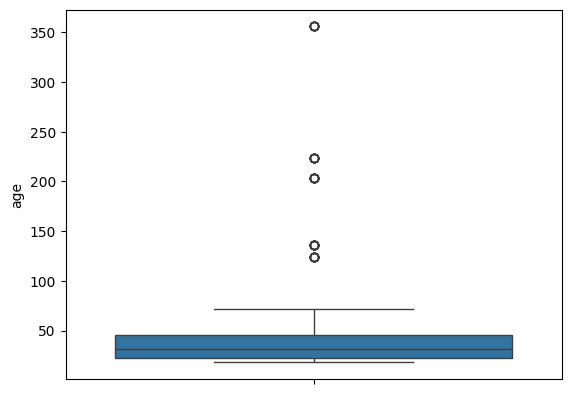

In [16]:
sns.boxplot(df_medical["age"])
plt.show()

In [17]:
# finidng the numerica columns in the dataset to check for outliers and we will use IQR method to remove the outliers from the dataset.
numeric_columns=df_medical.select_dtypes(['float64','int64']).columns
numeric_columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='object')

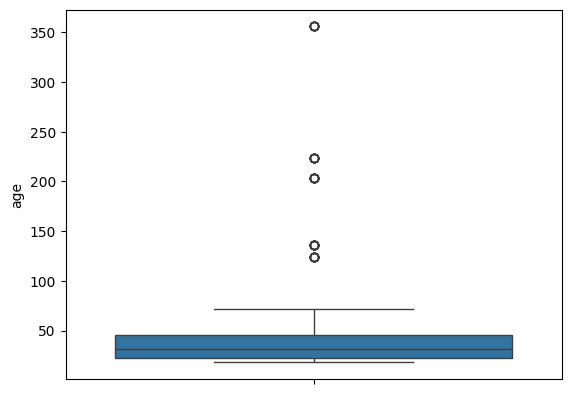

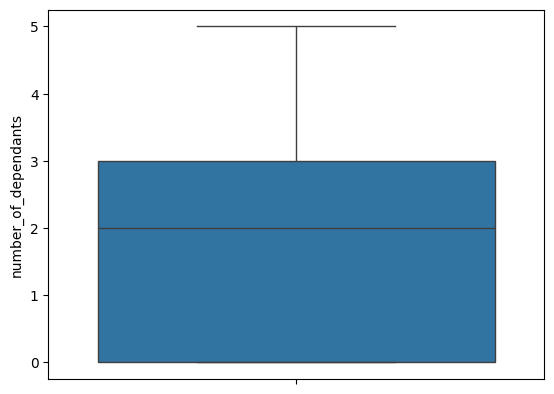

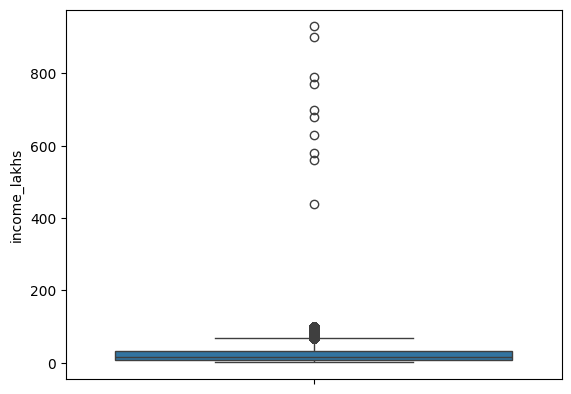

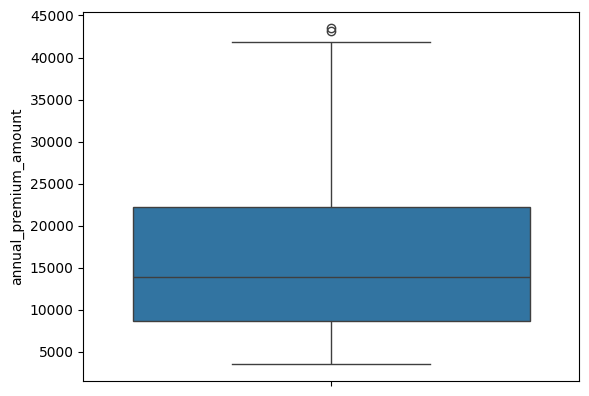

In [18]:
for col in numeric_columns:
          sns.boxplot(df_medical[col])
          plt.show()

In [19]:
# if we see there are so much out lier in the dataset and we will use IQR method to remove the outliers from the dataset.
# hence we are considering onnly max age is 100 hence remaining data values will be removed 
df_medical=df_medical[df_medical.age<100]

In [20]:
df_medical.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49942.000000,49942.000000,49942.000000,49942.000000
mean,34.403648,1.717853,23.022186,15767.897041
std,13.682354,1.492130,24.225309,8418.981981
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13929.000000
75%,45.000000,3.000000,31.000000,22275.000000
max,72.000000,5.000000,930.000000,43471.000000


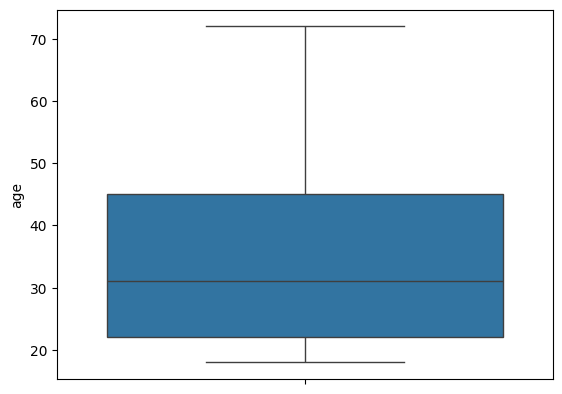

In [21]:
# ploting age 

sns.boxplot(df_medical["age"])
plt.show()

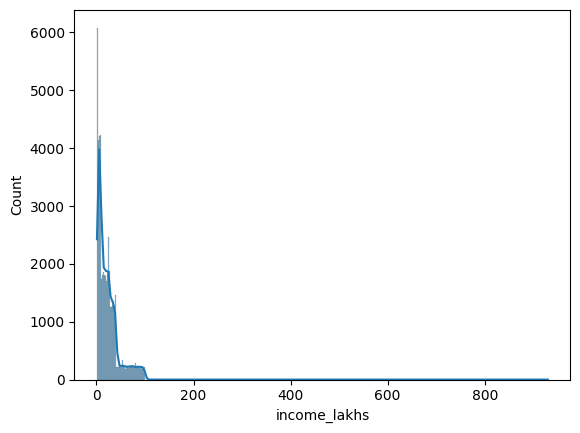

In [22]:
# now lets look for income column and see. let  me plot the distributions how the incomes distributed 

sns.histplot(df_medical["income_lakhs"],kde=True)
plt.show()

In [23]:
# Finindg lower and upper bounds for the outliers using IQR method and removing the outliers from the dataset.
def get_iqr_bounds(df,col):
          q1= df[col].quantile(.25)
          q3= df[col].quantile(.75)
          iqr=q3-q1
          lower_bound=q1-1.5*iqr
          upper_bound=q3+1.5*iqr
          return lower_bound, upper_bound

In [24]:
#based on the historgram the incokes isn 100K max wie becvaue income in lask and it is msoctlyu 0 to 100 so above them are outliers 
# hence we have to correct it 

lower_bound,upper_bound=get_iqr_bounds(df_medical,"income_lakhs")
lower_bound,upper_bound



(np.float64(-29.0), np.float64(67.0))

Practically speaks the upper bound is 67 but parctically 67L is not that much upper bound 
so we have to discuss with business to settle down what exactly we required and makje the upper limit
use 0.999 quantitle as practical 

In [25]:
quantile_threshold = df_medical["income_lakhs"].quantile(0.999)

In [26]:
quantile_threshold

np.float64(100.0)

In [27]:
## for backup (temp)

df_medical_temp = pd.read_excel(r'D:\codebasics\machine_learning\project\project_1_datacleaning_&_EDA_resources\premiums.xlsx')

In [28]:
df_medical_temp["Income_Lakhs"].head(10)

0    930
1    900
2    790
3    770
4    700
5    680
6    630
7    580
8    560
9    440
Name: Income_Lakhs, dtype: int64

In [29]:
df_medical_temp["Income_Lakhs"].describe()

count    50000.000000
mean        23.018200
std         24.219197
min          1.000000
25%          7.000000
50%         17.000000
75%         31.000000
max        930.000000
Name: Income_Lakhs, dtype: float64

In [30]:
df_medical_temp.describe()

,Age,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.593480,1.712080,23.018200,15768.116320
std,15.000437,1.498248,24.219197,8419.839675
min,18.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13929.000000
75%,45.000000,3.000000,31.000000,22275.250000
max,356.000000,5.000000,930.000000,43471.000000


In [31]:
df_medical_temp= df_medical_temp[df_medical_temp["Income_Lakhs"] < quantile_threshold]

In [32]:
df_medical[df_medical.income_lakhs<=quantile_threshold].copy()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
10,45,Male,Southeast,Unmarried,0,Overweight,Regular,Salaried,> 40L,100,High blood pressure,Gold,27153
11,42,Male,Southeast,Married,2,Underweight,Regular,Freelancer,> 40L,100,Thyroid,Gold,25573
12,23,Male,Southeast,Unmarried,2,Normal,No Smoking,Freelancer,> 40L,100,No Disease,Silver,10883
13,23,Female,Southeast,Unmarried,0,Underweight,No Smoking,Salaried,> 40L,100,No Disease,Silver,12422
14,18,Female,Southwest,Unmarried,0,Obesity,No Smoking,Salaried,> 40L,100,No Disease,Silver,13048
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,48,Female,Southwest,Married,2,Overweight,No Smoking,Salaried,<10L,1,No Disease,Silver,18652
49996,34,Female,Southeast,Unmarried,0,Overweight,Occasional,Salaried,<10L,1,No Disease,Silver,17053
49997,24,Female,Northeast,Unmarried,1,Normal,No Smoking,Salaried,<10L,1,No Disease,Bronze,8008
49998,24,Male,Southeast,Unmarried,0,Normal,No Smoking,Salaried,<10L,1,No Disease,Silver,11668


In [33]:
df_medical = df_medical[
    df_medical["income_lakhs"] <= quantile_threshold
].copy()

In [34]:
df_medical.income_lakhs.describe()

count    49932.000000
mean        22.887006
std         22.168871
min          1.000000
25%          7.000000
50%         17.000000
75%         31.000000
max        100.000000
Name: income_lakhs, dtype: float64

<Axes: xlabel='Income_Lakhs', ylabel='Count'>

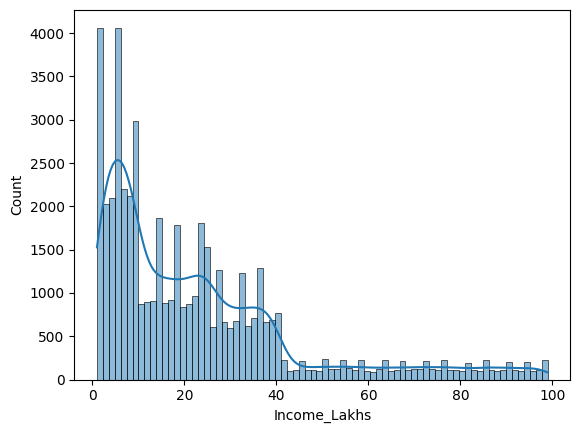

In [35]:
sns.histplot(df_medical_temp["Income_Lakhs"],kde=True)

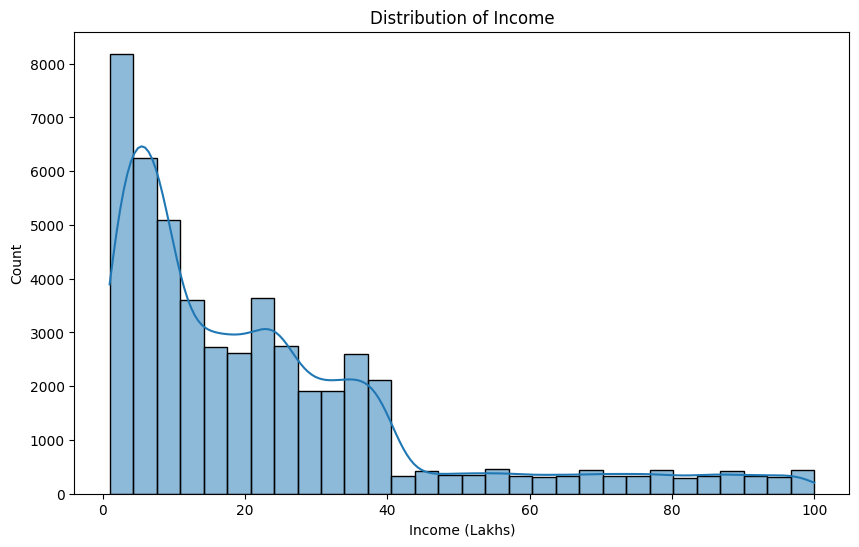

In [36]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_medical,
    x="income_lakhs",
    bins=30,
    kde=True
)

plt.xlabel("Income (Lakhs)")
plt.ylabel("Count")
plt.title("Distribution of Income")
plt.show()

In [37]:
df_medical[df_medical["income_lakhs"]<quantile_threshold].shape

(49832, 13)

In [38]:
df_medical.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
10,45,Male,Southeast,Unmarried,0,Overweight,Regular,Salaried,> 40L,100,High blood pressure,Gold,27153
11,42,Male,Southeast,Married,2,Underweight,Regular,Freelancer,> 40L,100,Thyroid,Gold,25573
12,23,Male,Southeast,Unmarried,2,Normal,No Smoking,Freelancer,> 40L,100,No Disease,Silver,10883
13,23,Female,Southeast,Unmarried,0,Underweight,No Smoking,Salaried,> 40L,100,No Disease,Silver,12422
14,18,Female,Southwest,Unmarried,0,Obesity,No Smoking,Salaried,> 40L,100,No Disease,Silver,13048


In [39]:
quantile_threshold

np.float64(100.0)

In [40]:
df_medical[df_medical["income_lakhs"] <= quantile_threshold]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
10,45,Male,Southeast,Unmarried,0,Overweight,Regular,Salaried,> 40L,100,High blood pressure,Gold,27153
11,42,Male,Southeast,Married,2,Underweight,Regular,Freelancer,> 40L,100,Thyroid,Gold,25573
12,23,Male,Southeast,Unmarried,2,Normal,No Smoking,Freelancer,> 40L,100,No Disease,Silver,10883
13,23,Female,Southeast,Unmarried,0,Underweight,No Smoking,Salaried,> 40L,100,No Disease,Silver,12422
14,18,Female,Southwest,Unmarried,0,Obesity,No Smoking,Salaried,> 40L,100,No Disease,Silver,13048
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,48,Female,Southwest,Married,2,Overweight,No Smoking,Salaried,<10L,1,No Disease,Silver,18652
49996,34,Female,Southeast,Unmarried,0,Overweight,Occasional,Salaried,<10L,1,No Disease,Silver,17053
49997,24,Female,Northeast,Unmarried,1,Normal,No Smoking,Salaried,<10L,1,No Disease,Bronze,8008
49998,24,Male,Southeast,Unmarried,0,Normal,No Smoking,Salaried,<10L,1,No Disease,Silver,11668


In [41]:
df_medical.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
10,45,Male,Southeast,Unmarried,0,Overweight,Regular,Salaried,> 40L,100,High blood pressure,Gold,27153
11,42,Male,Southeast,Married,2,Underweight,Regular,Freelancer,> 40L,100,Thyroid,Gold,25573
12,23,Male,Southeast,Unmarried,2,Normal,No Smoking,Freelancer,> 40L,100,No Disease,Silver,10883
13,23,Female,Southeast,Unmarried,0,Underweight,No Smoking,Salaried,> 40L,100,No Disease,Silver,12422
14,18,Female,Southwest,Unmarried,0,Obesity,No Smoking,Salaried,> 40L,100,No Disease,Silver,13048


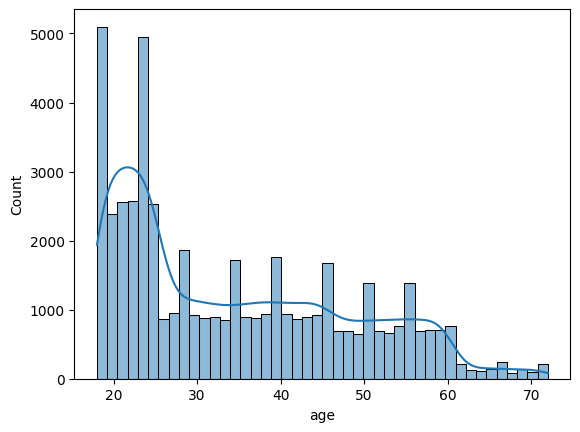

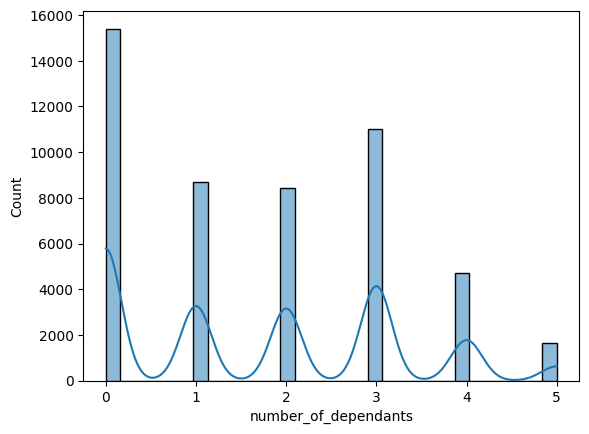

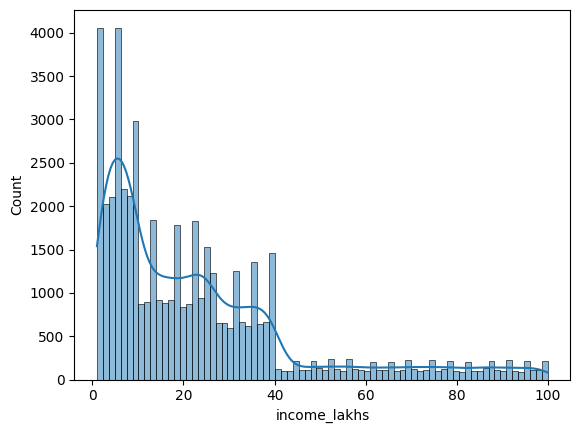

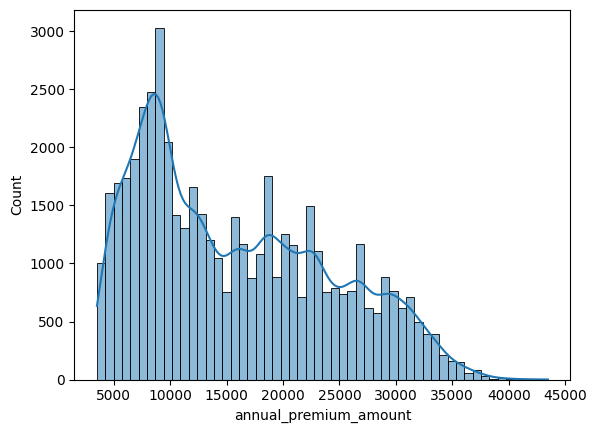

In [42]:
for col in numeric_columns:
          sns.histplot(df_medical[col],kde=True)
          plt.show()

In [43]:
df_medical.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
10,45,Male,Southeast,Unmarried,0,Overweight,Regular,Salaried,> 40L,100,High blood pressure,Gold,27153
11,42,Male,Southeast,Married,2,Underweight,Regular,Freelancer,> 40L,100,Thyroid,Gold,25573
12,23,Male,Southeast,Unmarried,2,Normal,No Smoking,Freelancer,> 40L,100,No Disease,Silver,10883
13,23,Female,Southeast,Unmarried,0,Underweight,No Smoking,Salaried,> 40L,100,No Disease,Silver,12422
14,18,Female,Southwest,Unmarried,0,Obesity,No Smoking,Salaried,> 40L,100,No Disease,Silver,13048


<Axes: xlabel='age', ylabel='annual_premium_amount'>

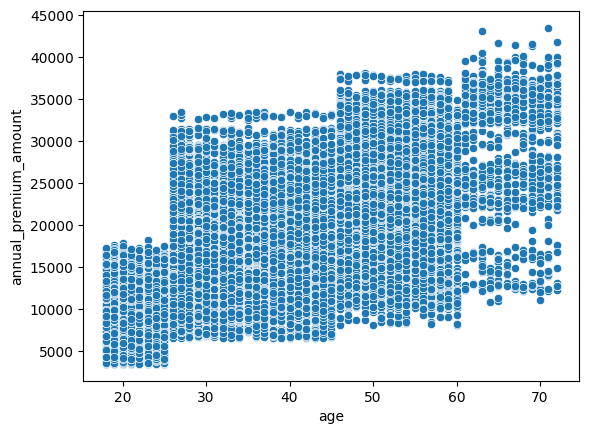

In [44]:
# Bivariate Analysis like age and income usuallty both are continous variables hence we can use scatter plot to see the relationship between them.
sns.scatterplot(df_medical,x="age", y ="annual_premium_amount")

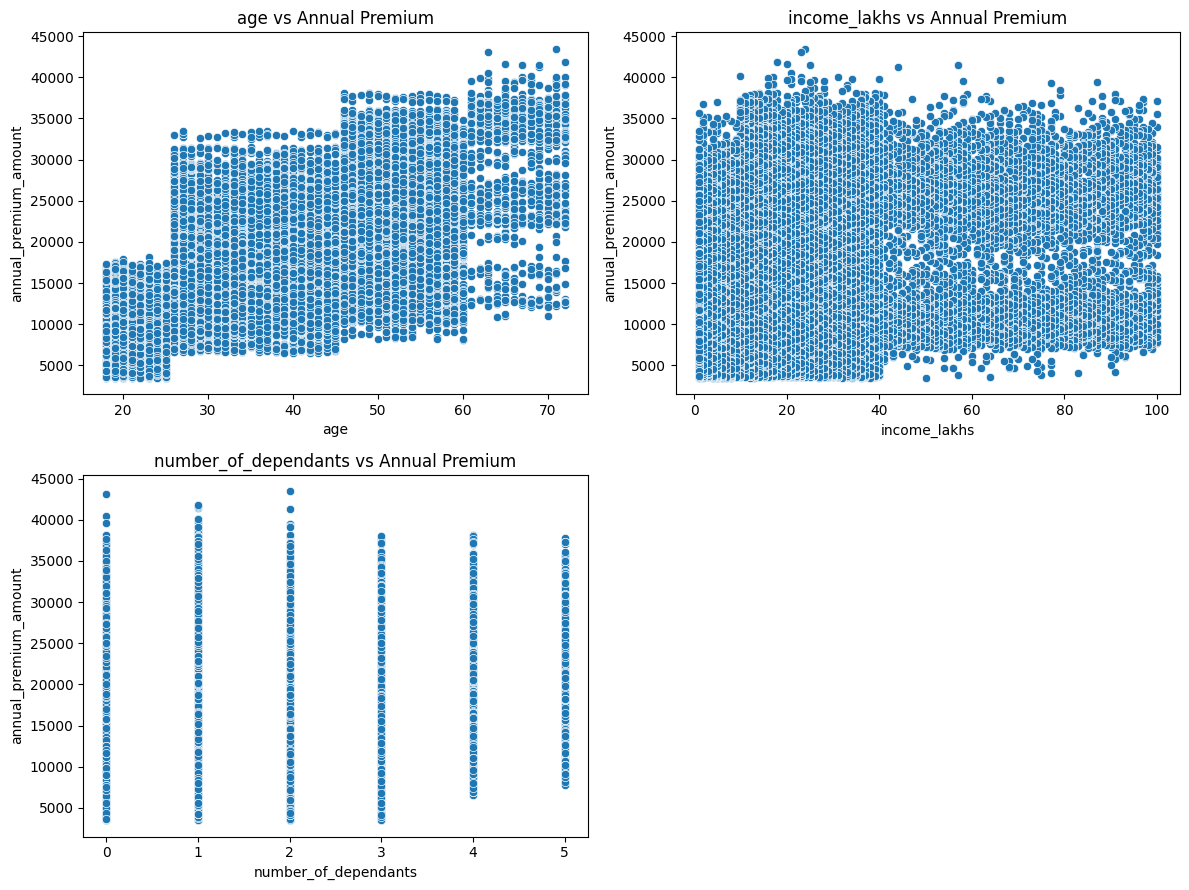

In [45]:
variables = ["age", "income_lakhs", "number_of_dependants"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, var in zip(axes.flat, variables):
    sns.scatterplot(
        data=df_medical,
        x=var,
        y="annual_premium_amount",
        ax=ax
    )
    ax.set_title(f"{var} vs Annual Premium")

# Turn off the unused 4th plot
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

In [46]:
#now we will deal with categorical variabels 
cat_cols = df_medical.select_dtypes(include="object").columns
print(cat_cols)

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')


In [47]:
# i want to print the unique values from each categorical column to see how many unique values are there and what are they.

for col in cat_cols:
          unique_vales= df_medical[col].unique()
          print(f" The columne is {col} and , ===> the unique values are : {unique_vales}")

 The columne is gender and , ===> the unique values are : ['Male' 'Female']
 The columne is region and , ===> the unique values are : ['Southeast' 'Southwest' 'Northwest' 'Northeast']
 The columne is marital_status and , ===> the unique values are : ['Unmarried' 'Married']
 The columne is bmi_category and , ===> the unique values are : ['Overweight' 'Underweight' 'Normal' 'Obesity']
 The columne is smoking_status and , ===> the unique values are : ['Regular' 'No Smoking' 'Occasional' nan 'Does Not Smoke' 'Not Smoking'
 'Smoking=0']
 The columne is employment_status and , ===> the unique values are : ['Salaried' 'Freelancer' 'Self-Employed' nan]
 The columne is income_level and , ===> the unique values are : ['> 40L' '25L - 40L' '10L - 25L' '<10L' nan]
 The columne is medical_history and , ===> the unique values are : ['High blood pressure' 'Thyroid' 'No Disease' 'Diabetes'
 'High blood pressure & Heart disease' 'Diabetes & High blood pressure'
 'Heart disease' 'Diabetes & Thyroid' 'Dia

In [48]:
# these is some issues with smoking_status like Smoking=0, Does Not Smoke, Not Smoking all are same hence we will replace them with No Smoking
df_medical["smoking_status"]= df_medical["smoking_status"].replace({
       'Smoking=0' :    'No Smoking',
       'Does Not Smoke' : 'No Smoking',
       'Not Smoking' : 'No Smoking',
})

In [49]:
df_medical["smoking_status"].unique()

array(['Regular', 'No Smoking', 'Occasional', nan], dtype=object)

In [50]:
# CHECKING GENERALIZATION OF CATEGORICAL VARIABLES
# normalize means it wil show the percentage of each value in the column instead of count.
per_gender = df_medical["gender"].value_counts(normalize=True)
per_gender

gender
Male      0.549607
Female    0.450393
Name: proportion, dtype: float64

<Axes: xlabel='gender', ylabel='proportion'>

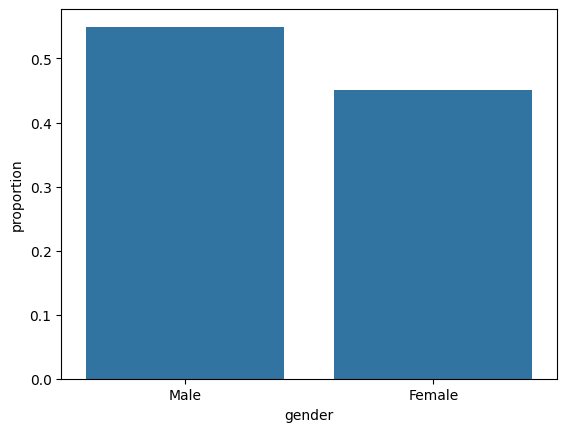

In [51]:
sns.barplot(per_gender)

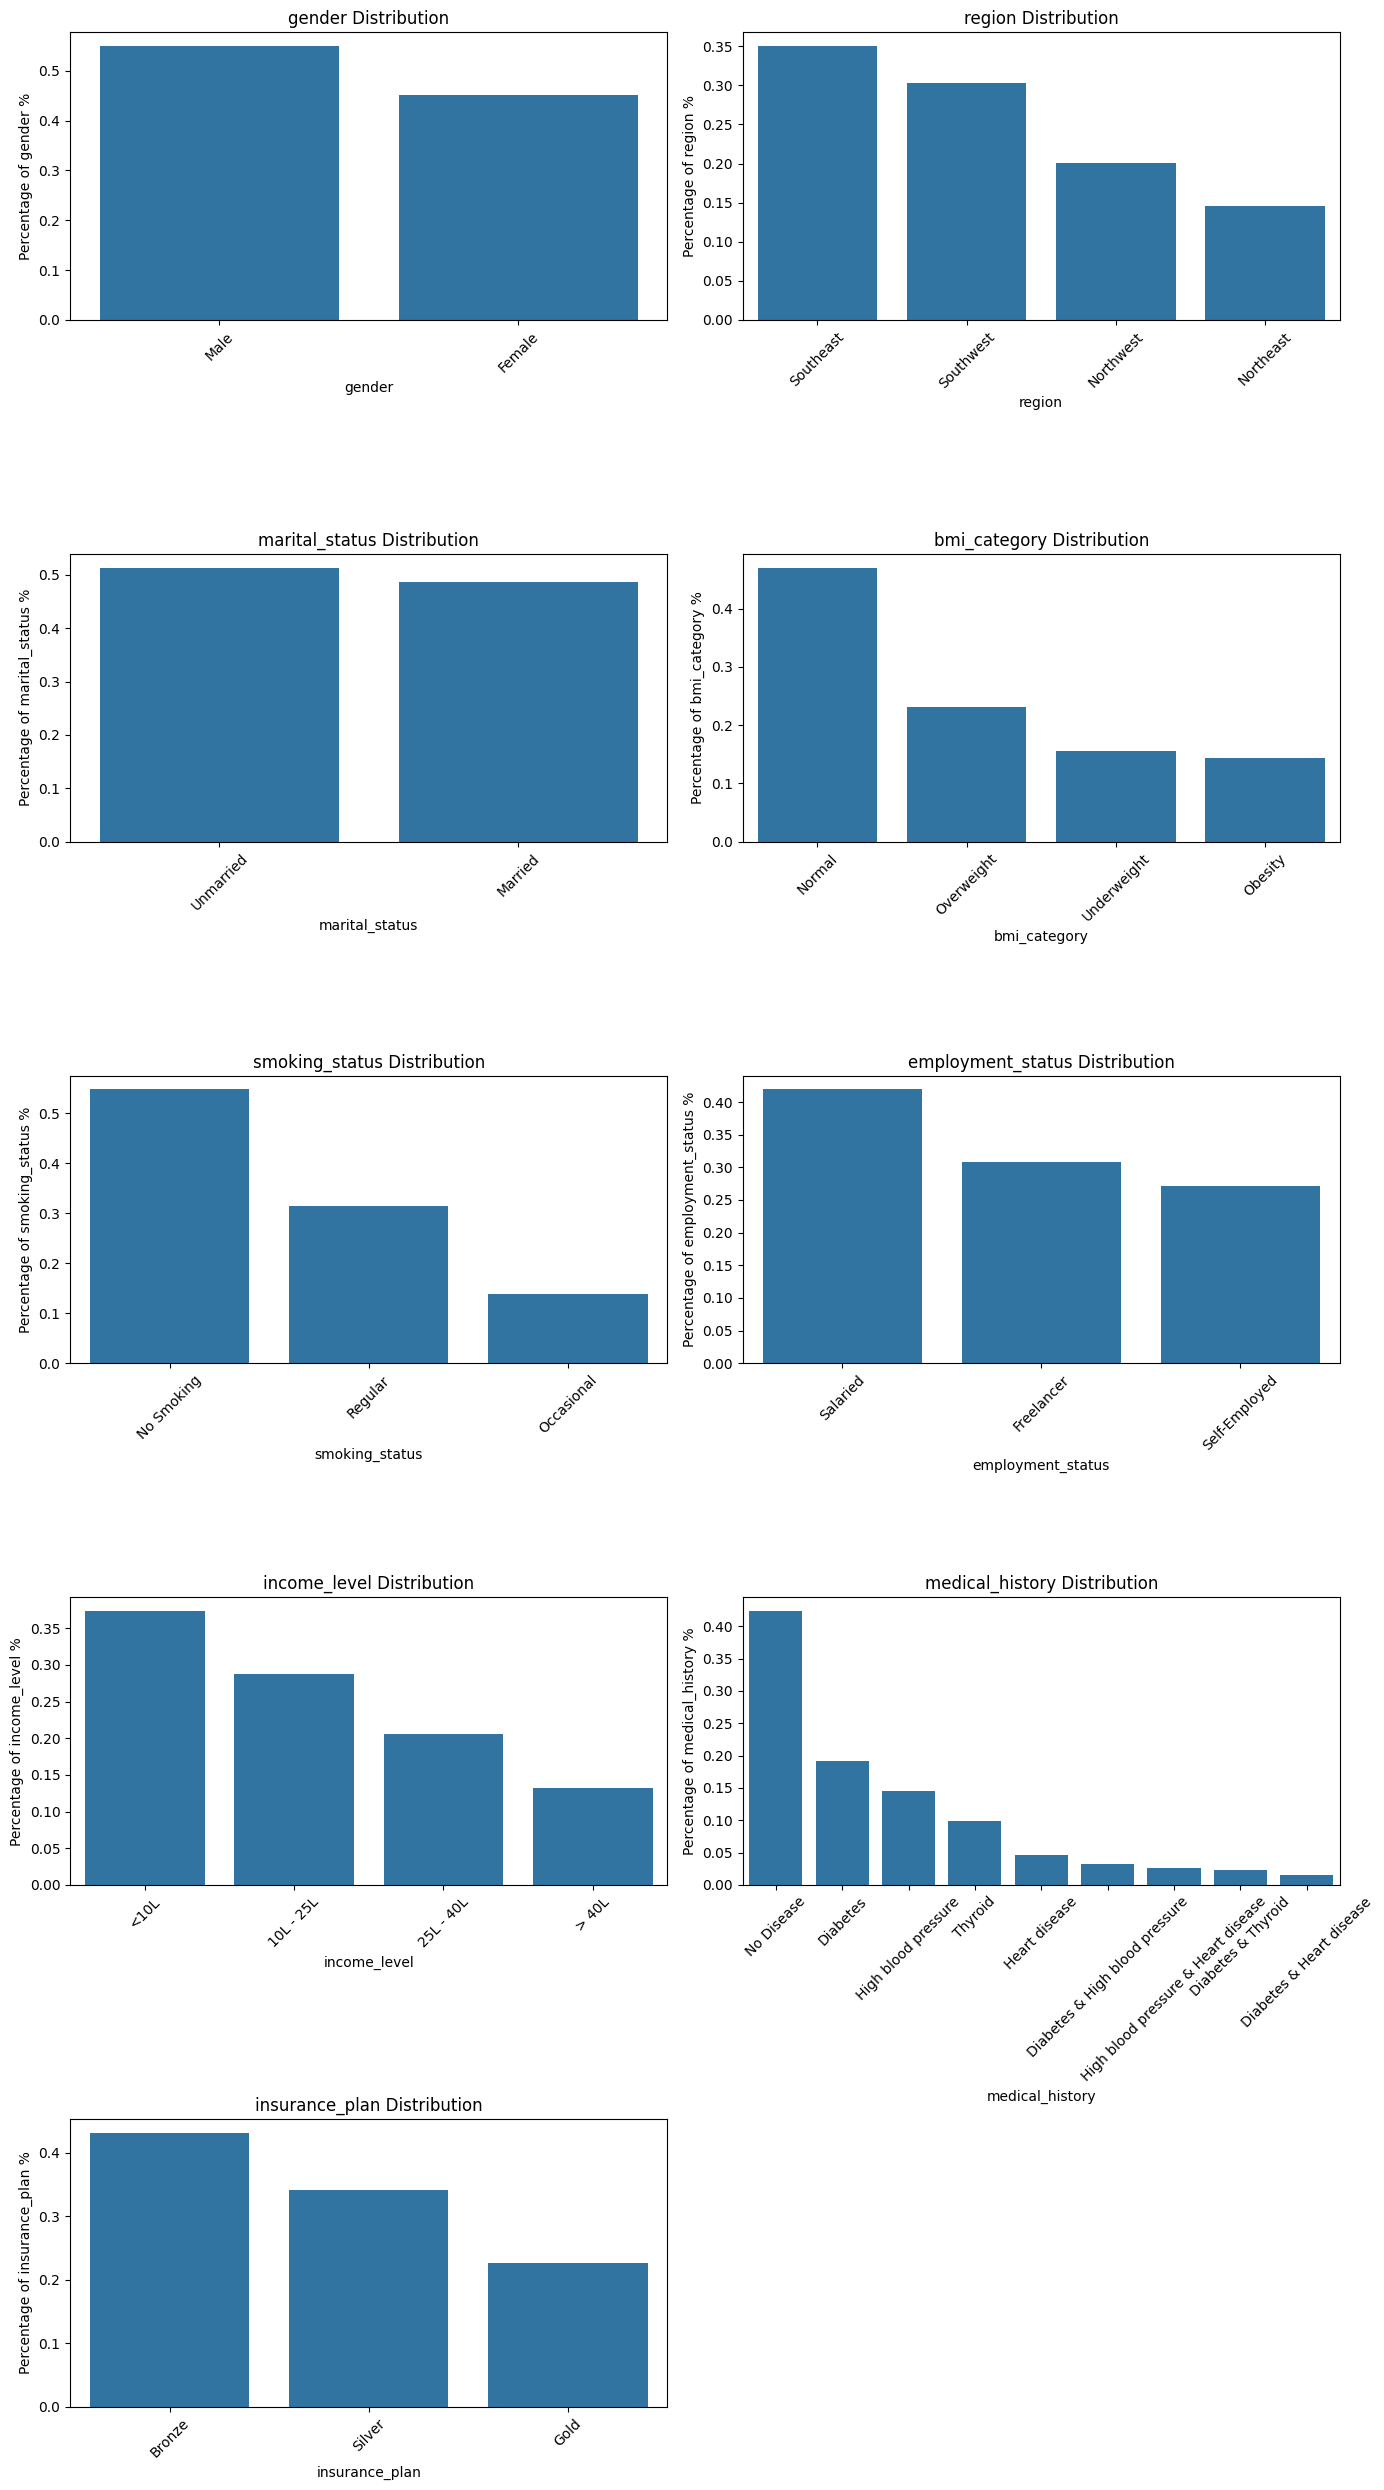

In [52]:

import math

cat_cols = df_medical.select_dtypes(
    include=["object", "category"]
).columns

n_cols = 2
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 5 * n_rows)
)

axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    
    per_cat = df_medical[col].value_counts(normalize=True)
    
    sns.barplot(
        x=per_cat.index,
        y=per_cat.values,
        ax=ax
    )
    
    ax.set_title(f"{col} Distribution")
    ax.set_xlabel(col)
    ax.set_ylabel(f"Percentage of {col} %")
    ax.tick_params(axis="x", rotation=45)

# Hide empty subplots
for ax in axes[len(cat_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [53]:
#How many observations fall into each combination of two categories?
# get it throug corsstab from pandas

df_medical_crosstab = pd.crosstab(df_medical["income_level"], df_medical["insurance_plan"],normalize=True)
df_medical_crosstab

insurance_plan,Bronze,Gold,Silver
income_level,,,
10L - 25L,0.106332,0.077726,0.103828
25L - 40L,0.073780,0.056992,0.075122
<10L,0.244937,0.018650,0.109918
> 40L,0.006591,0.073199,0.052926


<Axes: xlabel='insurance_plan', ylabel='income_level'>

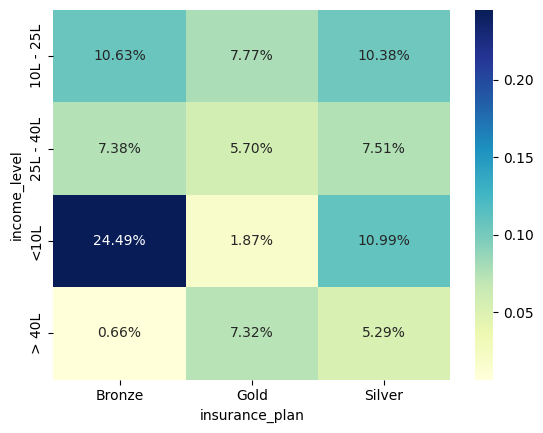

In [54]:
sns.heatmap(df_medical_crosstab, annot=True, fmt=".2%", cmap="YlGnBu")

# FEATURE ENGINEERING ----> VERY IMPORTANT 
after cleaning data , i have couple of features so hence we have to find how the data useful 
****Make the data useful for the model***

In [55]:
df_medical.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
10,45,Male,Southeast,Unmarried,0,Overweight,Regular,Salaried,> 40L,100,High blood pressure,Gold,27153
11,42,Male,Southeast,Married,2,Underweight,Regular,Freelancer,> 40L,100,Thyroid,Gold,25573
12,23,Male,Southeast,Unmarried,2,Normal,No Smoking,Freelancer,> 40L,100,No Disease,Silver,10883
13,23,Female,Southeast,Unmarried,0,Underweight,No Smoking,Salaried,> 40L,100,No Disease,Silver,12422
14,18,Female,Southwest,Unmarried,0,Obesity,No Smoking,Salaried,> 40L,100,No Disease,Silver,13048


In [56]:
df_medical.medical_history.unique()

### we have key feature in the dataset which is medical_history  
# but these are textual data and we have to convert them into numerical data 
# using one hot encoding or label encoding and we will use one hot encoding

array(['High blood pressure', 'Thyroid', 'No Disease', 'Diabetes',
       'High blood pressure & Heart disease',
       'Diabetes & High blood pressure', 'Heart disease',
       'Diabetes & Thyroid', 'Diabetes & Heart disease'], dtype=object)

In [57]:
#business suggested that , we have to assign the scores based on amecical history data

risk_scores={
          "Diabetes": 6,
          "Heart disease" : 8,
          "Thyroid" : 5,
          'No Disease' : 0,
          "None" : 0,
          "High blood pressure" : 6
}


In [58]:
# now we have to split the medcial_hosty values so that we can guess the risk sore 
df_medical["medical_history"].str.split(" & ", expand=True)

,0,1
10,High blood pressure,None
11,Thyroid,None
12,No Disease,None
13,No Disease,None
14,No Disease,None
...,...,...
49995,No Disease,None
49996,No Disease,None
49997,No Disease,None
49998,No Disease,None


In [59]:
# we have to store diseases in new columns 1 or more currently we have max 2 diseases
df_medical[["Disease_1", "Diesease_2"]] = df_medical["medical_history"].str.split(" & ", expand=True)

In [60]:
df_medical.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,Disease_1,Diesease_2
10,45,Male,Southeast,Unmarried,0,Overweight,Regular,Salaried,> 40L,100,High blood pressure,Gold,27153,High blood pressure,None
11,42,Male,Southeast,Married,2,Underweight,Regular,Freelancer,> 40L,100,Thyroid,Gold,25573,Thyroid,None
12,23,Male,Southeast,Unmarried,2,Normal,No Smoking,Freelancer,> 40L,100,No Disease,Silver,10883,No Disease,None
13,23,Female,Southeast,Unmarried,0,Underweight,No Smoking,Salaried,> 40L,100,No Disease,Silver,12422,No Disease,None
14,18,Female,Southwest,Unmarried,0,Obesity,No Smoking,Salaried,> 40L,100,No Disease,Silver,13048,No Disease,None


In [61]:
# filling NA values with None.

df_medical["Disease_1"].fillna("None", inplace=True)
df_medical["Diesease_2"].fillna("None", inplace=True)

C:\Users\vinod\AppData\Local\Temp\ipykernel_21188\2623088673.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_medical["Disease_1"].fillna("None", inplace=True)
C:\Users\vinod\AppData\Local\Temp\ipykernel_21188\2623088673.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [62]:
df_medical.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,Disease_1,Diesease_2
10,45,Male,Southeast,Unmarried,0,Overweight,Regular,Salaried,> 40L,100,High blood pressure,Gold,27153,High blood pressure,None
11,42,Male,Southeast,Married,2,Underweight,Regular,Freelancer,> 40L,100,Thyroid,Gold,25573,Thyroid,None
12,23,Male,Southeast,Unmarried,2,Normal,No Smoking,Freelancer,> 40L,100,No Disease,Silver,10883,No Disease,None
13,23,Female,Southeast,Unmarried,0,Underweight,No Smoking,Salaried,> 40L,100,No Disease,Silver,12422,No Disease,None
14,18,Female,Southwest,Unmarried,0,Obesity,No Smoking,Salaried,> 40L,100,No Disease,Silver,13048,No Disease,None


In [63]:
# calculateing risk score based on the medical history and storing it in new column called risk_score
df_medical["total_risk_score"] = 0
for disease_col in ["Disease_1", "Diesease_2"]:
          df_medical['total_risk_score'] += df_medical[disease_col].map(risk_scores)

df_medical.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,Disease_1,Diesease_2,total_risk_score
10,45,Male,Southeast,Unmarried,0,Overweight,Regular,Salaried,> 40L,100,High blood pressure,Gold,27153,High blood pressure,None,6
11,42,Male,Southeast,Married,2,Underweight,Regular,Freelancer,> 40L,100,Thyroid,Gold,25573,Thyroid,None,5
12,23,Male,Southeast,Unmarried,2,Normal,No Smoking,Freelancer,> 40L,100,No Disease,Silver,10883,No Disease,None,0
13,23,Female,Southeast,Unmarried,0,Underweight,No Smoking,Salaried,> 40L,100,No Disease,Silver,12422,No Disease,None,0
14,18,Female,Southwest,Unmarried,0,Obesity,No Smoking,Salaried,> 40L,100,No Disease,Silver,13048,No Disease,None,0


In [64]:
#Normalize the risk score 
#The exact use of Min-Max normalization is to bring values in a common range, usually 0 to 1, so that large numbers don't dominate smaller numbers.
#min-max normalization formula is : (x - min) / (max - min)

max_risk_score = df_medical["total_risk_score"].max()
min_risk_score = df_medical["total_risk_score"].min()


df_medical["normalized_risk_score"] = (df_medical["total_risk_score"] - min_risk_score) / (max_risk_score - min_risk_score).round(3)



In [65]:
pd.options.display.float_format = "{:.3f}".format

In [66]:
df_medical.head(20)


,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,Disease_1,Diesease_2,total_risk_score,normalized_risk_score
10,45,Male,Southeast,Unmarried,0,Overweight,Regular,Salaried,> 40L,100,High blood pressure,Gold,27153,High blood pressure,None,6,0.429
11,42,Male,Southeast,Married,2,Underweight,Regular,Freelancer,> 40L,100,Thyroid,Gold,25573,Thyroid,None,5,0.357
12,23,Male,Southeast,Unmarried,2,Normal,No Smoking,Freelancer,> 40L,100,No Disease,Silver,10883,No Disease,None,0,0.000
13,23,Female,Southeast,Unmarried,0,Underweight,No Smoking,Salaried,> 40L,100,No Disease,Silver,12422,No Disease,None,0,0.000
14,18,Female,Southwest,Unmarried,0,Obesity,No Smoking,Salaried,> 40L,100,No Disease,Silver,13048,No Disease,None,0,0.000
15,30,Male,Northwest,Married,5,Normal,No Smoking,Salaried,> 40L,100,High blood pressure,Gold,22144,High blood pressure,None,6,0.429
16,20,Female,Southeast,Unmarried,1,Overweight,No Smoking,Freelancer,> 40L,100,No Disease,Silver,11028,No Disease,None,0,0.000
17,33,Male,Northeast,Married,3,Obesity,No Smoking,Freelancer,> 40L,100,High blood pressure,Gold,25947,High blood pressure,None,6,0.429
18,50,Male,Southwest,Unmarried,0,Normal,No Smoking,Freelancer,> 40L,100,High blood pressure,Gold,26508,High blood pressure,None,6,0.429
19,39,Female,Southeast,Unmarried,0,Normal,No Smoking,Salaried,> 40L,100,Diabetes,Gold,21757,Diabetes,None,6,0.429


In [67]:
# insurcne plans 

df_medical.insurance_plan.unique()


#assign numerical values to insurance plans 

df_medical["insurance_plan"] = df_medical["insurance_plan"].map( {"Bronze": 1, "Silver": 2, "Gold": 3} )

df_medical.head(20)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,Disease_1,Diesease_2,total_risk_score,normalized_risk_score
10,45,Male,Southeast,Unmarried,0,Overweight,Regular,Salaried,> 40L,100,High blood pressure,3,27153,High blood pressure,None,6,0.429
11,42,Male,Southeast,Married,2,Underweight,Regular,Freelancer,> 40L,100,Thyroid,3,25573,Thyroid,None,5,0.357
12,23,Male,Southeast,Unmarried,2,Normal,No Smoking,Freelancer,> 40L,100,No Disease,2,10883,No Disease,None,0,0.000
13,23,Female,Southeast,Unmarried,0,Underweight,No Smoking,Salaried,> 40L,100,No Disease,2,12422,No Disease,None,0,0.000
14,18,Female,Southwest,Unmarried,0,Obesity,No Smoking,Salaried,> 40L,100,No Disease,2,13048,No Disease,None,0,0.000
15,30,Male,Northwest,Married,5,Normal,No Smoking,Salaried,> 40L,100,High blood pressure,3,22144,High blood pressure,None,6,0.429
16,20,Female,Southeast,Unmarried,1,Overweight,No Smoking,Freelancer,> 40L,100,No Disease,2,11028,No Disease,None,0,0.000
17,33,Male,Northeast,Married,3,Obesity,No Smoking,Freelancer,> 40L,100,High blood pressure,3,25947,High blood pressure,None,6,0.429
18,50,Male,Southwest,Unmarried,0,Normal,No Smoking,Freelancer,> 40L,100,High blood pressure,3,26508,High blood pressure,None,6,0.429
19,39,Female,Southeast,Unmarried,0,Normal,No Smoking,Salaried,> 40L,100,Diabetes,3,21757,Diabetes,None,6,0.429


In [68]:

df_medical.income_level.unique()

array(['> 40L', '25L - 40L', '10L - 25L', '<10L', nan], dtype=object)

In [69]:
df_medical.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,Disease_1,Diesease_2,total_risk_score,normalized_risk_score
10,45,Male,Southeast,Unmarried,0,Overweight,Regular,Salaried,> 40L,100,High blood pressure,3,27153,High blood pressure,None,6,0.429
11,42,Male,Southeast,Married,2,Underweight,Regular,Freelancer,> 40L,100,Thyroid,3,25573,Thyroid,None,5,0.357
12,23,Male,Southeast,Unmarried,2,Normal,No Smoking,Freelancer,> 40L,100,No Disease,2,10883,No Disease,None,0,0.000
13,23,Female,Southeast,Unmarried,0,Underweight,No Smoking,Salaried,> 40L,100,No Disease,2,12422,No Disease,None,0,0.000
14,18,Female,Southwest,Unmarried,0,Obesity,No Smoking,Salaried,> 40L,100,No Disease,2,13048,No Disease,None,0,0.000


In [70]:
print(len(df_medical))
print(len(df_medical_temp))

49932
49890


In [71]:
# Income Level  

#assign numerical values to income levels 

df_medical["income_level"] = df_medical["income_level"].map( {"<10L": 1, "10L-20L": 2, "25L - 40L": 3 , "> 40L": 4} )

df_medical.head(20)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,Disease_1,Diesease_2,total_risk_score,normalized_risk_score
10,45,Male,Southeast,Unmarried,0,Overweight,Regular,Salaried,4.000,100,High blood pressure,3,27153,High blood pressure,None,6,0.429
11,42,Male,Southeast,Married,2,Underweight,Regular,Freelancer,4.000,100,Thyroid,3,25573,Thyroid,None,5,0.357
12,23,Male,Southeast,Unmarried,2,Normal,No Smoking,Freelancer,4.000,100,No Disease,2,10883,No Disease,None,0,0.000
13,23,Female,Southeast,Unmarried,0,Underweight,No Smoking,Salaried,4.000,100,No Disease,2,12422,No Disease,None,0,0.000
14,18,Female,Southwest,Unmarried,0,Obesity,No Smoking,Salaried,4.000,100,No Disease,2,13048,No Disease,None,0,0.000
15,30,Male,Northwest,Married,5,Normal,No Smoking,Salaried,4.000,100,High blood pressure,3,22144,High blood pressure,None,6,0.429
16,20,Female,Southeast,Unmarried,1,Overweight,No Smoking,Freelancer,4.000,100,No Disease,2,11028,No Disease,None,0,0.000
17,33,Male,Northeast,Married,3,Obesity,No Smoking,Freelancer,4.000,100,High blood pressure,3,25947,High blood pressure,None,6,0.429
18,50,Male,Southwest,Unmarried,0,Normal,No Smoking,Freelancer,4.000,100,High blood pressure,3,26508,High blood pressure,None,6,0.429
19,39,Female,Southeast,Unmarried,0,Normal,No Smoking,Salaried,4.000,100,Diabetes,3,21757,Diabetes,None,6,0.429


In [72]:

df_medical.head(20)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,Disease_1,Diesease_2,total_risk_score,normalized_risk_score
10,45,Male,Southeast,Unmarried,0,Overweight,Regular,Salaried,4.000,100,High blood pressure,3,27153,High blood pressure,None,6,0.429
11,42,Male,Southeast,Married,2,Underweight,Regular,Freelancer,4.000,100,Thyroid,3,25573,Thyroid,None,5,0.357
12,23,Male,Southeast,Unmarried,2,Normal,No Smoking,Freelancer,4.000,100,No Disease,2,10883,No Disease,None,0,0.000
13,23,Female,Southeast,Unmarried,0,Underweight,No Smoking,Salaried,4.000,100,No Disease,2,12422,No Disease,None,0,0.000
14,18,Female,Southwest,Unmarried,0,Obesity,No Smoking,Salaried,4.000,100,No Disease,2,13048,No Disease,None,0,0.000
15,30,Male,Northwest,Married,5,Normal,No Smoking,Salaried,4.000,100,High blood pressure,3,22144,High blood pressure,None,6,0.429
16,20,Female,Southeast,Unmarried,1,Overweight,No Smoking,Freelancer,4.000,100,No Disease,2,11028,No Disease,None,0,0.000
17,33,Male,Northeast,Married,3,Obesity,No Smoking,Freelancer,4.000,100,High blood pressure,3,25947,High blood pressure,None,6,0.429
18,50,Male,Southwest,Unmarried,0,Normal,No Smoking,Freelancer,4.000,100,High blood pressure,3,26508,High blood pressure,None,6,0.429
19,39,Female,Southeast,Unmarried,0,Normal,No Smoking,Salaried,4.000,100,Diabetes,3,21757,Diabetes,None,6,0.429


Nominal columns
### Nominal Columns

* Nominal columns contain **categories or names**.
* There is **no specific order or ranking** between the values.
* They are mainly used to **identify different groups**.
* Examples: **Gender, City, Blood Group, Department, Payment Mode**.
* For example, **HR, IT, and Finance** are categories, but none is higher or lower than the others.

Nominal columns are categorical columns where the values are just names/labels, and there is no natural order or ranking between them.

In [73]:
#now i will do one hot encoding for all nominla colums
nominal_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status']

In [74]:
df_medical_1= pd.get_dummies(df_medical, columns=nominal_cols, drop_first=True,dtype=int)

In [75]:
df_medical.head(20)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,Disease_1,Diesease_2,total_risk_score,normalized_risk_score
10,45,Male,Southeast,Unmarried,0,Overweight,Regular,Salaried,4.000,100,High blood pressure,3,27153,High blood pressure,None,6,0.429
11,42,Male,Southeast,Married,2,Underweight,Regular,Freelancer,4.000,100,Thyroid,3,25573,Thyroid,None,5,0.357
12,23,Male,Southeast,Unmarried,2,Normal,No Smoking,Freelancer,4.000,100,No Disease,2,10883,No Disease,None,0,0.000
13,23,Female,Southeast,Unmarried,0,Underweight,No Smoking,Salaried,4.000,100,No Disease,2,12422,No Disease,None,0,0.000
14,18,Female,Southwest,Unmarried,0,Obesity,No Smoking,Salaried,4.000,100,No Disease,2,13048,No Disease,None,0,0.000
15,30,Male,Northwest,Married,5,Normal,No Smoking,Salaried,4.000,100,High blood pressure,3,22144,High blood pressure,None,6,0.429
16,20,Female,Southeast,Unmarried,1,Overweight,No Smoking,Freelancer,4.000,100,No Disease,2,11028,No Disease,None,0,0.000
17,33,Male,Northeast,Married,3,Obesity,No Smoking,Freelancer,4.000,100,High blood pressure,3,25947,High blood pressure,None,6,0.429
18,50,Male,Southwest,Unmarried,0,Normal,No Smoking,Freelancer,4.000,100,High blood pressure,3,26508,High blood pressure,None,6,0.429
19,39,Female,Southeast,Unmarried,0,Normal,No Smoking,Salaried,4.000,100,Diabetes,3,21757,Diabetes,None,6,0.429


In [76]:
df_medical_1.head(20)


,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,Disease_1,Diesease_2,total_risk_score,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
10,45,0,4.000,100,High blood pressure,3,27153,High blood pressure,None,6,...,1,0,1,0,1,0,0,1,1,0
11,42,2,4.000,100,Thyroid,3,25573,Thyroid,None,5,...,1,0,0,0,0,1,0,1,0,0
12,23,2,4.000,100,No Disease,2,10883,No Disease,None,0,...,1,0,1,0,0,0,0,0,0,0
13,23,0,4.000,100,No Disease,2,12422,No Disease,None,0,...,1,0,1,0,0,1,0,0,1,0
14,18,0,4.000,100,No Disease,2,13048,No Disease,None,0,...,0,1,1,1,0,0,0,0,1,0
15,30,5,4.000,100,High blood pressure,3,22144,High blood pressure,None,6,...,0,0,0,0,0,0,0,0,1,0
16,20,1,4.000,100,No Disease,2,11028,No Disease,None,0,...,1,0,1,0,1,0,0,0,0,0
17,33,3,4.000,100,High blood pressure,3,25947,High blood pressure,None,6,...,0,0,0,1,0,0,0,0,0,0
18,50,0,4.000,100,High blood pressure,3,26508,High blood pressure,None,6,...,0,1,1,0,0,0,0,0,0,0
19,39,0,4.000,100,Diabetes,3,21757,Diabetes,None,6,...,1,0,1,0,0,0,0,0,1,0


In [77]:
df_medical_1.info

<bound method DataFrame.info of        age  number_of_dependants  income_level  income_lakhs  \
10      45                     0         4.000           100   
11      42                     2         4.000           100   
12      23                     2         4.000           100   
13      23                     0         4.000           100   
14      18                     0         4.000           100   
...    ...                   ...           ...           ...   
49995   48                     2         1.000             1   
49996   34                     0         1.000             1   
49997   24                     1         1.000             1   
49998   24                     0         1.000             1   
49999   19                     2         1.000             1   

           medical_history  insurance_plan  annual_premium_amount  \
10     High blood pressure               3                  27153   
11                 Thyroid               3                  2

In [78]:
## feature engineering
## removed used or not useful or not a best for model building features and created new features like normalized_risk_score and total_risk_score
## i care about normailze_risk_score 
df_medical_2 = df_medical_1.drop(['medical_history','Disease_1', 'Diesease_2', 'total_risk_score'], axis=1)
df_medical_2.head(3)  

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
10,45,0,4.000,100,3,27153,0.429,1,0,1,0,1,0,1,0,0,1,1,0
11,42,2,4.000,100,3,25573,0.357,1,0,1,0,0,0,0,1,0,1,0,0
12,23,2,4.000,100,2,10883,0.000,1,0,1,0,1,0,0,0,0,0,0,0


## Correlation Analysis

Correlation analysis is used to understand the **relationship between two numerical variables**.

It tells us:

* Whether two variables are related.
* The **direction** of the relationship.
* The **strength** of the relationship.

The correlation value ranges from **-1 to +1**:

* **+1** → Strong positive relationship
* **0** → No linear relationship
* **-1** → Strong negative relationship

For example, we can check the correlation between **Age, Income, Annual Premium Amount, and Total Risk Score**.

> **Note:** Correlation shows the relationship between variables, but it does not mean that one variable causes the other.


In [79]:
## Correlation Analysis

medical_corr = df_medical_2.corr()

medical_corr

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
age,1.000,0.416,0.036,0.025,0.496,0.768,0.443,-0.002,0.000,0.003,-0.003,-0.543,0.153,0.153,-0.116,0.066,0.059,-0.008,0.315
number_of_dependants,0.416,1.000,0.009,0.006,0.257,0.415,0.372,-0.003,0.002,0.003,-0.000,-0.842,0.115,0.110,-0.094,0.072,0.095,0.067,0.116
income_level,0.036,0.009,1.000,0.916,0.534,0.340,0.017,0.081,-0.004,-0.000,0.011,-0.017,-0.003,0.010,0.001,-0.002,0.027,-0.157,0.166
income_lakhs,0.025,0.006,0.916,1.000,0.411,0.243,0.010,0.039,-0.005,-0.001,0.010,-0.011,0.000,0.007,-0.001,0.002,0.011,-0.100,0.110
insurance_plan,0.496,0.257,0.534,0.411,1.000,0.834,0.261,0.034,-0.003,0.004,-0.001,-0.317,0.095,0.099,-0.074,0.037,0.059,-0.042,0.224
annual_premium_amount,0.768,0.415,0.340,0.243,0.834,1.000,0.520,0.064,-0.005,0.008,-0.004,-0.516,0.250,0.187,-0.135,0.060,0.199,-0.005,0.289
normalized_risk_score,0.443,0.372,0.017,0.010,0.261,0.520,1.000,-0.004,-0.006,0.002,-0.000,-0.434,0.101,0.103,-0.088,0.071,0.094,0.060,0.136
gender_Male,-0.002,-0.003,0.081,0.039,0.034,0.064,-0.004,1.000,-0.003,-0.003,0.002,0.004,-0.032,0.081,-0.043,-0.045,0.305,0.006,0.001
region_Northwest,0.000,0.002,-0.004,-0.005,-0.003,-0.005,-0.006,-0.003,1.000,-0.368,-0.331,-0.001,-0.002,0.001,-0.002,-0.001,-0.000,0.005,0.000
region_Southeast,0.003,0.003,-0.000,-0.001,0.004,0.008,0.002,-0.003,-0.368,1.000,-0.484,-0.004,0.006,0.003,0.000,-0.002,-0.000,-0.007,0.003


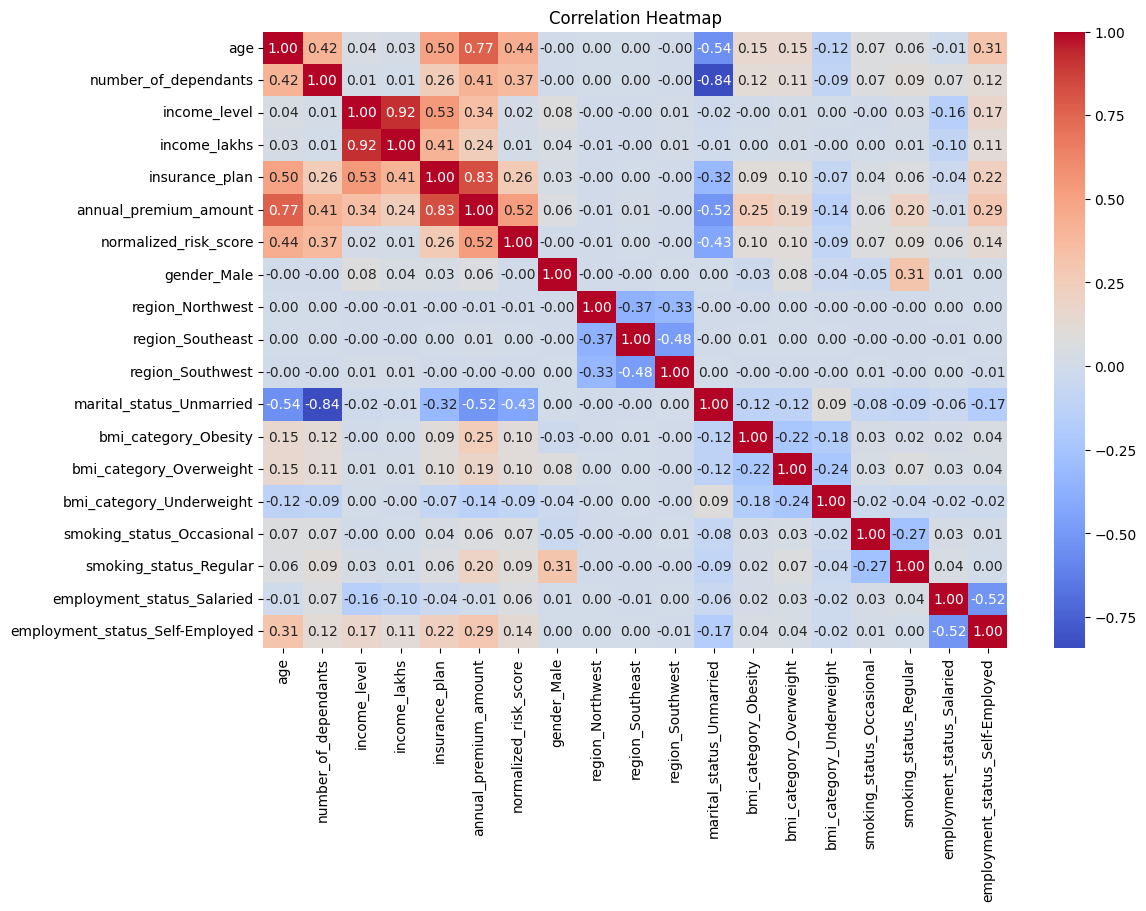

In [80]:
plt.figure(figsize=(12, 8))
sns.heatmap(medical_corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

## VIF Analysis

**VIF (Variance Inflation Factor)** is used to check whether the **independent/input variables are highly related to each other**.

This problem is called **multicollinearity**.

### How to understand VIF values

* **VIF = 1** → No multicollinearity
* **VIF 1–5** → Usually acceptable
* **VIF 5–10** → High multicollinearity
* **VIF > 10** → Very high multicollinearity

For example:

* **Age VIF = 1.5** → Low multicollinearity
* **Income VIF = 2.1** → Low multicollinearity
* **Premium VIF = 8.5** → High multicollinearity

> **In simple words:** VIF tells us whether our independent variables are highly related to each other.


In [81]:
df_medical_2["income_level"] = df_medical["income_level"].fillna(
    df_medical_2["income_level"].mode()[0]
)

In [82]:
df_medical_2.income_level.isna().sum()

np.int64(0)

In [83]:
X = df_medical_2.drop(['annual_premium_amount'], axis=1)
y = df_medical_2['annual_premium_amount']

In [84]:
# scaling is required 
# to make all varibes to in same order like age is 10 to 100 but premius amounts maby eb 100000000 to 20000000000 so it is quite diffucly to analys so make to 0 to 1 
from sklearn.preprocessing import MinMaxScaler

In [85]:
scaler = MinMaxScaler()
cols_to_scale  = ['age','number_of_dependants', 'income_level',  'income_lakhs', 'insurance_plan']
X[cols_to_scale] =  scaler.fit_transform(X[cols_to_scale])

X.describe()


,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,49932.000,49932.000,49932.000,49932.000,49932.000,49932.000,49932.000,49932.000,49932.000,49932.000,49932.000,49932.000,49932.000,49932.000,49932.000,49932.000,49932.000,49932.000
mean,0.304,0.344,0.270,0.221,0.397,0.292,0.550,0.201,0.350,0.303,0.513,0.143,0.231,0.155,0.138,0.314,0.419,0.272
std,0.253,0.298,0.389,0.224,0.392,0.287,0.498,0.401,0.477,0.460,0.500,0.350,0.422,0.362,0.345,0.464,0.493,0.445
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.074,0.000,0.000,0.061,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,0.241,0.400,0.000,0.162,0.500,0.357,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,0.500,0.600,0.667,0.303,0.500,0.429,1.000,0.000,1.000,1.000,1.000,0.000,0.000,0.000,0.000,1.000,1.000,1.000
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


In [86]:
# now cal;culating VIF

from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [87]:
X.isna().sum()

age                                0
number_of_dependants               0
income_level                       0
income_lakhs                       0
insurance_plan                     0
normalized_risk_score              0
gender_Male                        0
region_Northwest                   0
region_Southeast                   0
region_Southwest                   0
marital_status_Unmarried           0
bmi_category_Obesity               0
bmi_category_Overweight            0
bmi_category_Underweight           0
smoking_status_Occasional          0
smoking_status_Regular             0
employment_status_Salaried         0
employment_status_Self-Employed    0
dtype: int64

In [88]:
calculate_vif(X)

,Column,VIF
0,age,4.547
1,number_of_dependants,4.535
2,income_level,6.380
3,income_lakhs,8.837
4,insurance_plan,3.447
5,normalized_risk_score,2.688
6,gender_Male,2.412
7,region_Northwest,2.100
8,region_Southeast,2.920
9,region_Southwest,2.669


In [89]:
X_reduced = X.drop("income_level",axis="columns")
X_reduced.head()

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
10,0.500,0.000,1.000,1.000,0.429,1,0,1,0,1,0,1,0,0,1,1,0
11,0.444,0.400,1.000,1.000,0.357,1,0,1,0,0,0,0,1,0,1,0,0
12,0.093,0.400,1.000,0.500,0.000,1,0,1,0,1,0,0,0,0,0,0,0
13,0.093,0.000,1.000,0.500,0.000,0,0,1,0,1,0,0,1,0,0,1,0
14,0.000,0.000,1.000,0.500,0.000,0,0,0,1,1,1,0,0,0,0,1,0


In [90]:
calculate_vif(X_reduced)

,Column,VIF
0,age,4.546
1,number_of_dependants,4.526
2,income_lakhs,2.480
3,insurance_plan,3.446
4,normalized_risk_score,2.688
5,gender_Male,2.410
6,region_Northwest,2.100
7,region_Southeast,2.919
8,region_Southwest,2.669
9,marital_status_Unmarried,3.393


---Model Training ---

In [91]:
X_train,X_test,y_train,y_test = train_test_split(X_reduced,y,test_size=0.3,random_state=42)


# shape of the X_train, X_test, y_train, y_test features
print("x train: ",X_train.shape)
print("x test: ",X_test.shape)
print("y train: ",y_train.shape)
print("y test: ",y_test.shape)

x train:  (34952, 17)
x test:  (14980, 17)
y train:  (34952,)
y test:  (14980,)


In [92]:
# Linear Regressioin Model 

linear_model = LinearRegression()
linear_model.fit(X_train,y_train)
test_score = linear_model.score(X_test,y_test)
train_score = linear_model.score(X_train,y_train)

train_score,test_score 

# If train_score is more than test_score ==> over fit

(0.9277376674123938, 0.9292105238313381)

In [93]:
linear_model.coef_

array([11276.06074766,  -559.31963013,  -372.51827872, 12496.90956147,
        4849.67874168,   148.35841881,   -50.81240159,    29.66317744,
         -19.61808094,  -825.93794414,  3339.36558254,  1594.3378362 ,
         325.91793197,   715.94661443,  2204.66864898,   175.87681031,
         391.41578539])

In [94]:
linear_model.intercept_

np.float64(4708.949638217942)

In [95]:
feature_importance = linear_model.coef_
df_coef  = pd.DataFrame(feature_importance, index=X_test.columns, columns=["Coefficients"])

df_coef = df_coef.sort_values(by="Coefficients", ascending=True)



In [96]:
df_coef

,Coefficients
marital_status_Unmarried,-825.938
number_of_dependants,-559.320
income_lakhs,-372.518
region_Northwest,-50.812
region_Southwest,-19.618
region_Southeast,29.663
gender_Male,148.358
employment_status_Salaried,175.877
bmi_category_Underweight,325.918
employment_status_Self-Employed,391.416


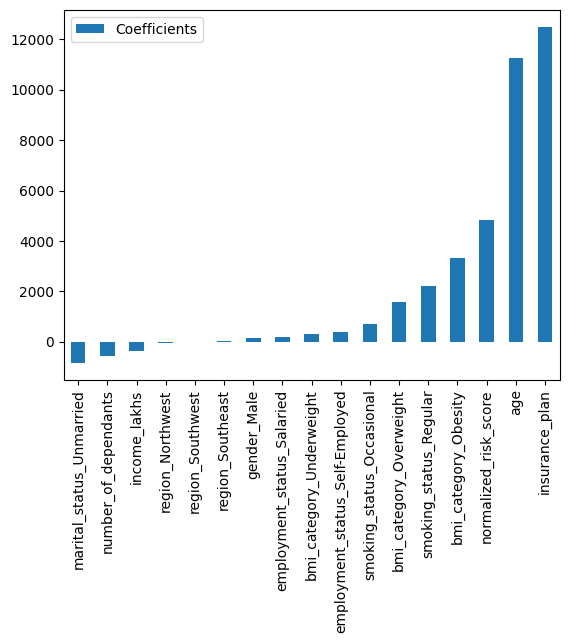

In [97]:
df_coef.plot(kind="bar")
plt.show()

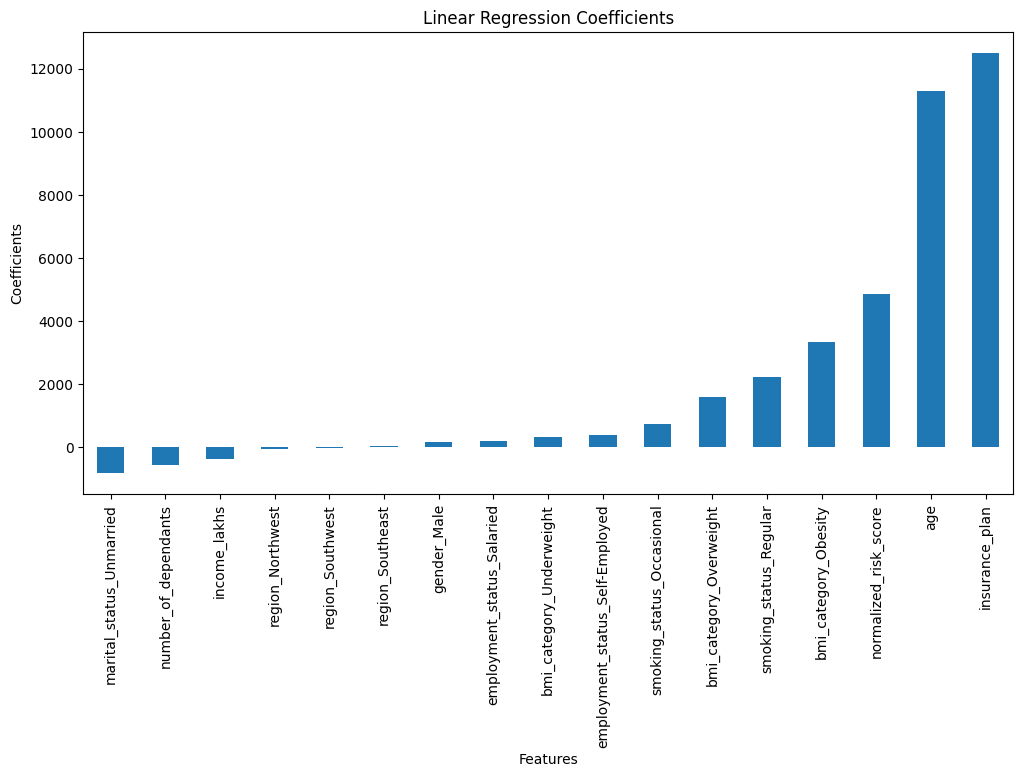

In [98]:
df_coef["Coefficients"].plot(kind="bar", figsize=(12, 6))

plt.xlabel("Features")
plt.ylabel("Coefficients")
plt.title("Linear Regression Coefficients")
plt.xticks(rotation=90)
plt.show()

In [99]:
ridge_model = Ridge(alpha=10)
ridge_model.fit(X_train,y_train)
test_score = ridge_model.score(X_test,y_test)
train_score = ridge_model.score(X_train,y_train)

train_score,test_score 



(0.9277338983578136, 0.9292069965848664)

In [100]:
# I'm trying my most liked model XGBoost
 
from xgboost import XGBRegressor

xgb_model = XGBRegressor()

xgb_model.fit(X_train,y_train)
test_score = xgb_model.score(X_test,y_test)
train_score = xgb_model.score(X_train,y_train)

train_score,test_score 

(0.9860689043998718, 0.9810581803321838)

<h1 > RandomizedSearchCV randomly tries different model settings and uses cross-validation to find a good set of settings for the model.</h1>

In [101]:
# Now we will see whihc params will imporve xbgboot more  so permutation combinatison we wqill try 

xgb_model = XGBRegressor()
param_grid = {
    'n_estimators': [20, 40, 50],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
}
random_search = RandomizedSearchCV(xgb_model, param_grid, n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)
random_search.best_score_

np.float64(0.9810075163841248)

In [102]:
random_search.best_params_

{'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1}

In [103]:
best_model = random_search.best_estimator_

In [104]:
feautes_imp = best_model.feature_importances_

In [105]:
feautes_imp

array([4.1264108e-01, 1.7038151e-04, 2.2131547e-04, 5.1711309e-01,
       1.8376114e-02, 1.8541321e-04, 1.4961800e-04, 2.7264029e-04,
       1.1686238e-04, 1.1958804e-05, 1.7798577e-02, 9.8347720e-03,
       1.1911681e-03, 4.0685567e-03, 1.7502867e-02, 2.1142577e-04,
       1.3412624e-04], dtype=float32)

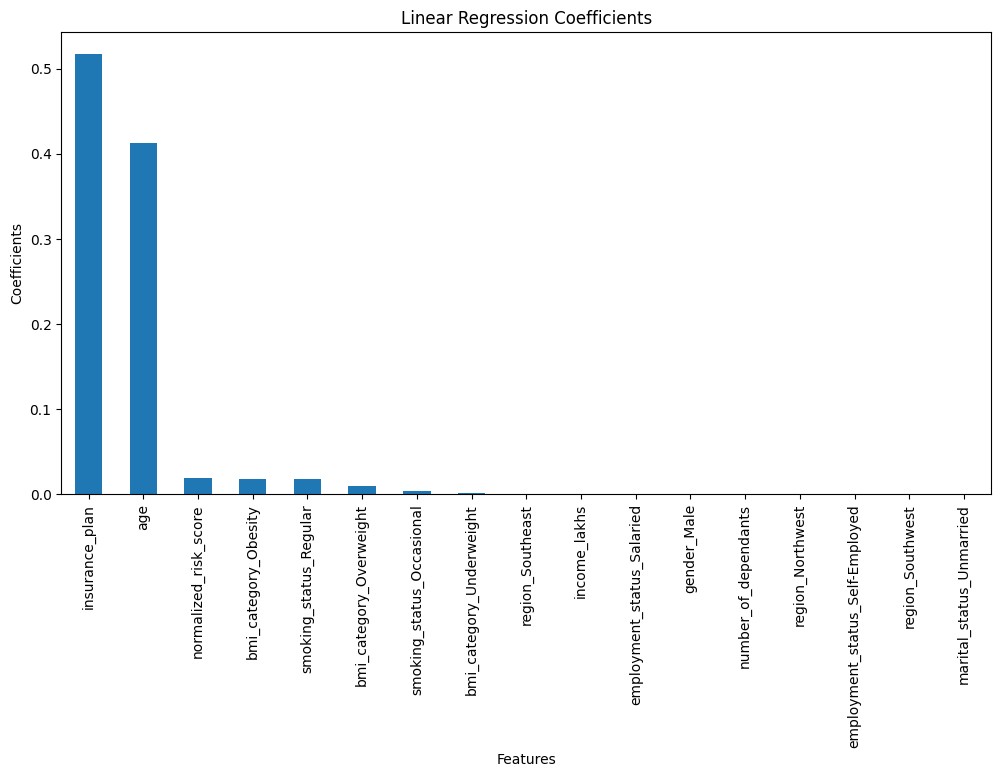

In [106]:

df_xgb_ecf = pd.DataFrame(feautes_imp, index=X_test.columns, columns=["Coefficients"])

df_xgb_ecf = df_xgb_ecf.sort_values(by="Coefficients", ascending=False)
df_xgb_ecf["Coefficients"].plot(kind="bar", figsize=(12, 6))

plt.xlabel("Features")
plt.ylabel("Coefficients")
plt.title("Linear Regression Coefficients")
plt.xticks(rotation=90)
plt.show()

<span style="color:red">

## Error Analysis

We analyze the difference between the actual and predicted values.

- Positive error → Model under-predicted
- Negative error → Model over-predicted
- Smaller error → Better prediction

</span>

## Error Analysis

Error analysis helps us understand how well the model's predictions match the actual values.

- **Error = Actual Value - Predicted Value**
- A **positive error** means the model predicted a lower value than the actual value.
- A **negative error** means the model predicted a higher value than the actual value.
- Smaller errors indicate better predictions.
- We analyze the errors to identify where the model is making larger mistakes.


## Error Analysis

We compare the prediction errors of Linear Regression and XGBoost.

- Linear Regression achieved an R² score of **92%**.
- XGBoost achieved an R² score of **98%**.
- We analyze the errors to understand the difference between actual and predicted values.
- Lower MAE and RMSE indicate smaller prediction errors.
- Error analysis helps us identify whether the model is making large prediction mistakes.

In [107]:
y_predict = best_model.predict(X_test)
residuals = y_predict - y_test
residuals_per = (residuals * 100 )/ y_test

result_df = pd.DataFrame( {
          "actuals" : y_test,
          "predicted" : y_predict,
          "diff" : residuals,
          "diff_percentage" : residuals_per
}
)

result_df.head(20)

,actuals,predicted,diff,diff_percentage
15051,19921,19677.072,-243.928,-1.224
40387,20229,20398.143,169.143,0.836
9845,6745,7147.850,402.850,5.973
18921,12056,9901.868,-2154.132,-17.868
44196,9067,6672.483,-2394.517,-26.409
31375,8103,7013.787,-1089.213,-13.442
46794,7230,7960.790,730.790,10.108
45529,13338,13699.506,361.506,2.710
45342,15892,15967.348,75.348,0.474
14378,7866,6594.589,-1271.411,-16.163


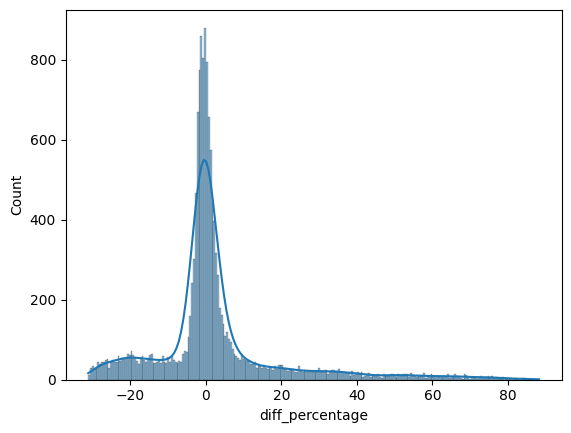

In [108]:
sns.histplot(result_df["diff_percentage"],kde=True)
plt.show()

In [109]:
extreme_error_threshold = 10  # You can adjust this threshold based on your domain knowledge or requirements
extreme_results_df = result_df[np.abs(result_df['diff_percentage']) > extreme_error_threshold]
extreme_results_df.head()

,actuals,predicted,diff,diff_percentage
18921,12056,9901.868,-2154.132,-17.868
44196,9067,6672.483,-2394.517,-26.409
31375,8103,7013.787,-1089.213,-13.442
46794,7230,7960.790,730.790,10.108
14378,7866,6594.589,-1271.411,-16.163


In [110]:
extreme_results_df.shape, result_df.shape

((4425, 4), (14980, 4))

In [111]:
# means 4425 rows have issue error 

In [112]:
extreme_errors_df = X_test.loc[extreme_results_df.index]
extreme_errors_df.head(2)

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
18921,0.093,0.000,0.222,0.500,0.000,0,0,1,0,1,0,0,0,0,0,1,0
44196,0.074,0.000,0.020,0.000,0.000,1,0,1,0,1,0,0,1,0,0,0,0


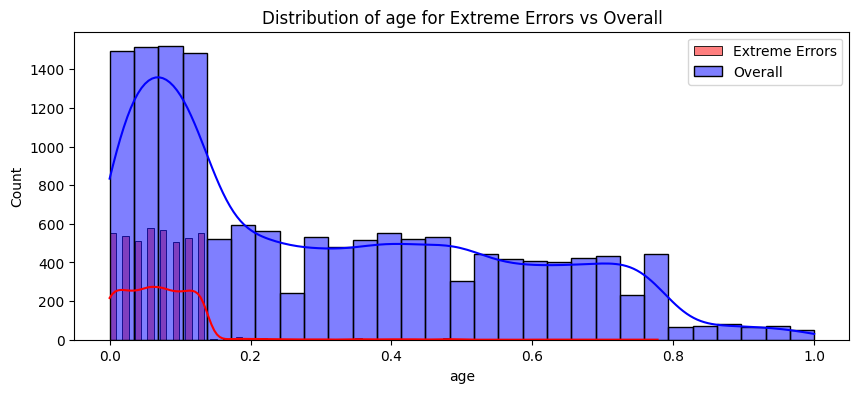

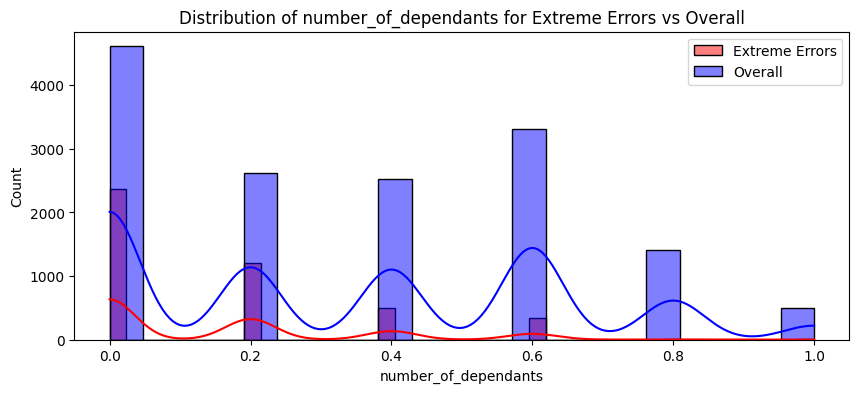

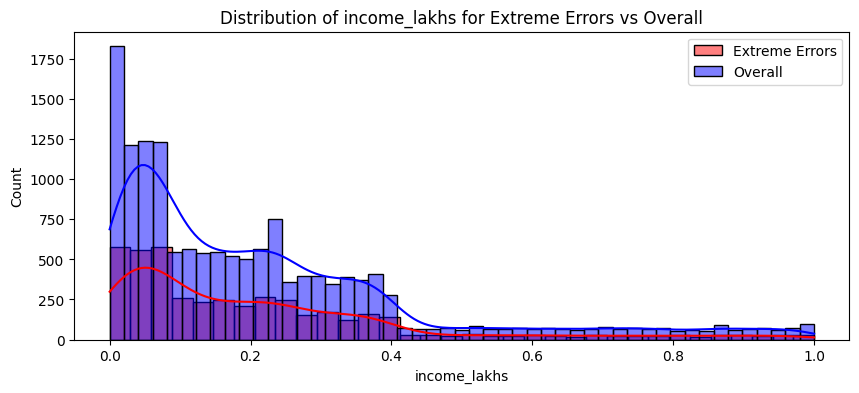

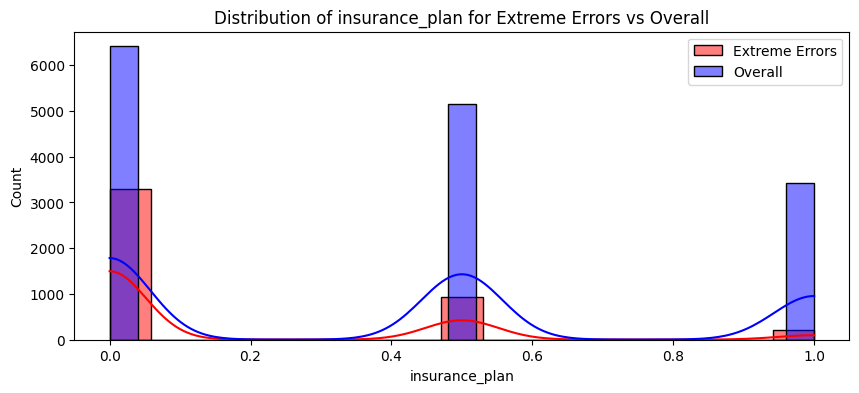

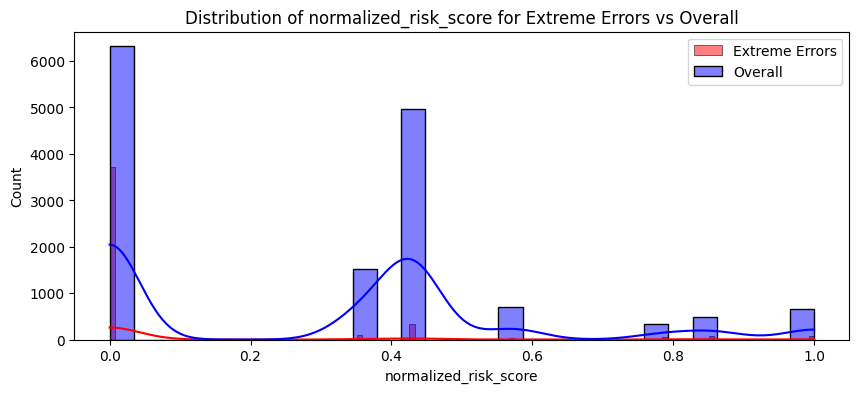

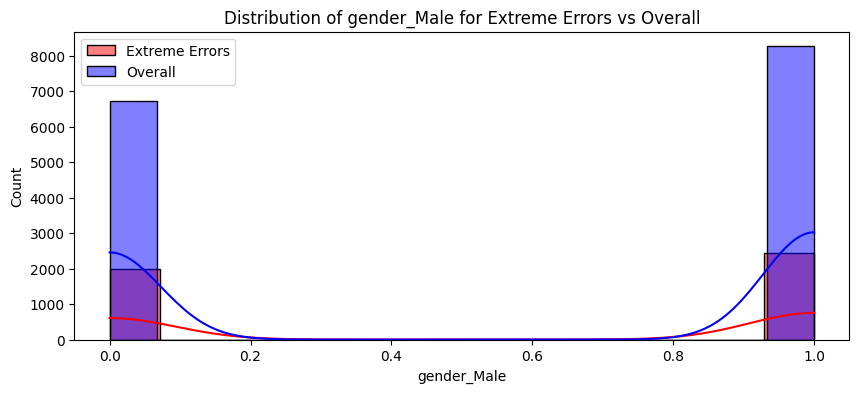

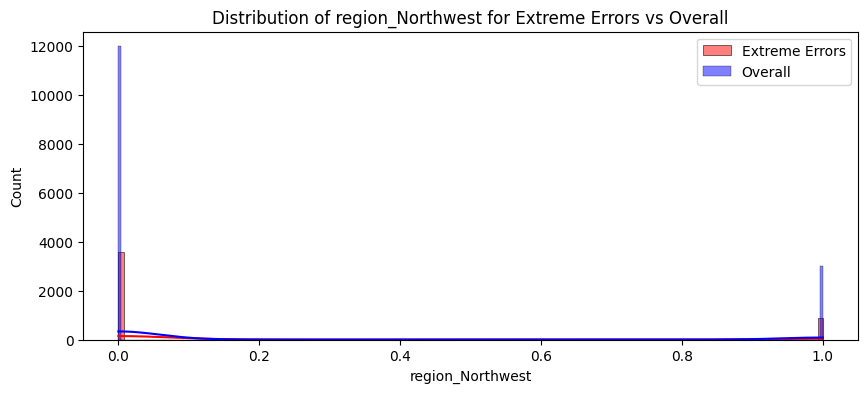

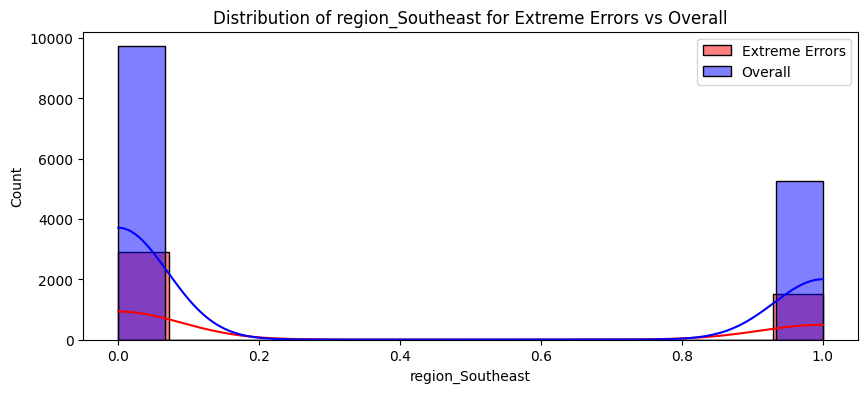

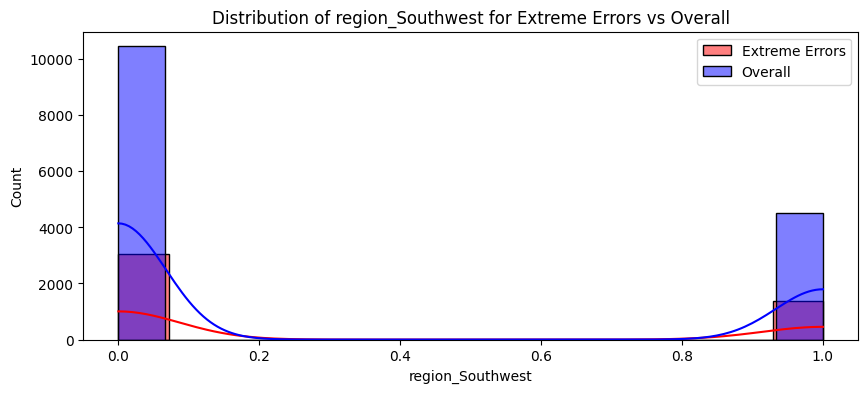

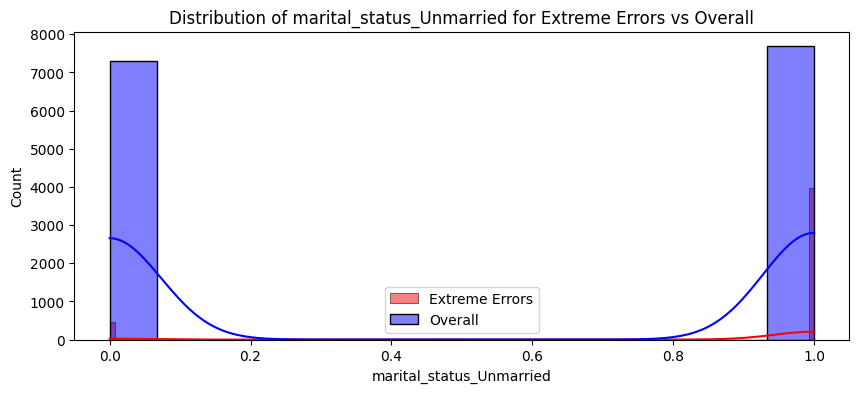

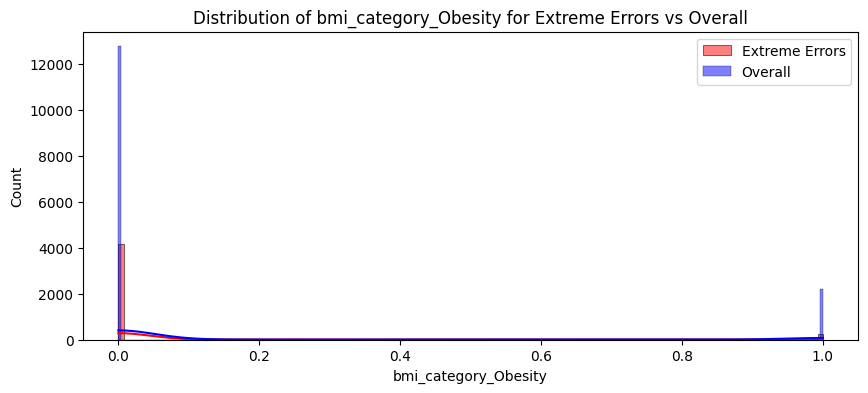

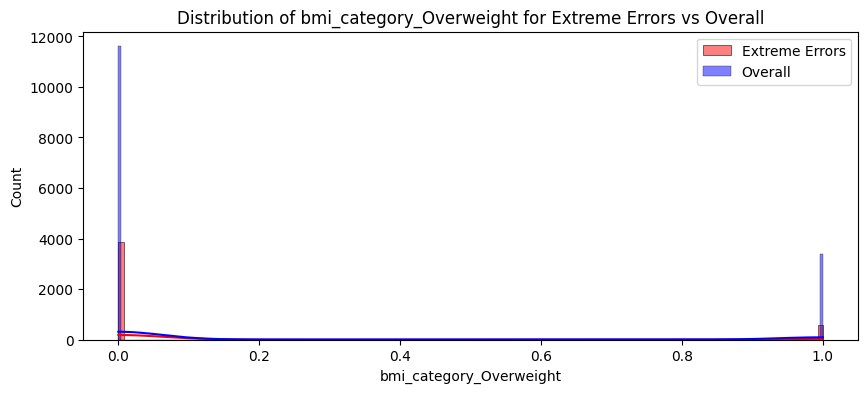

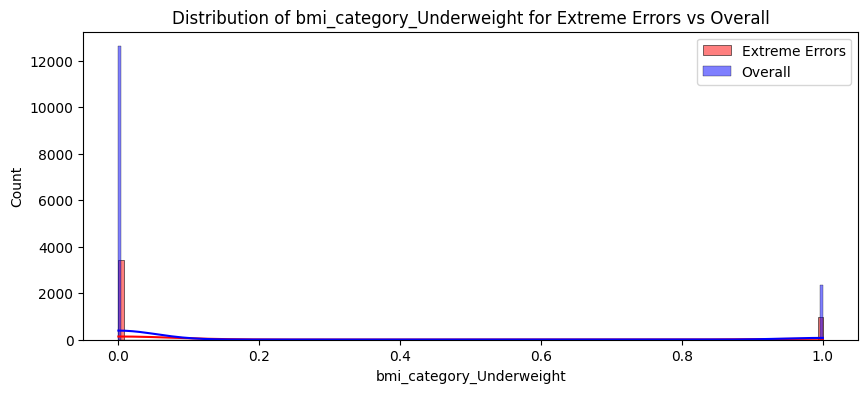

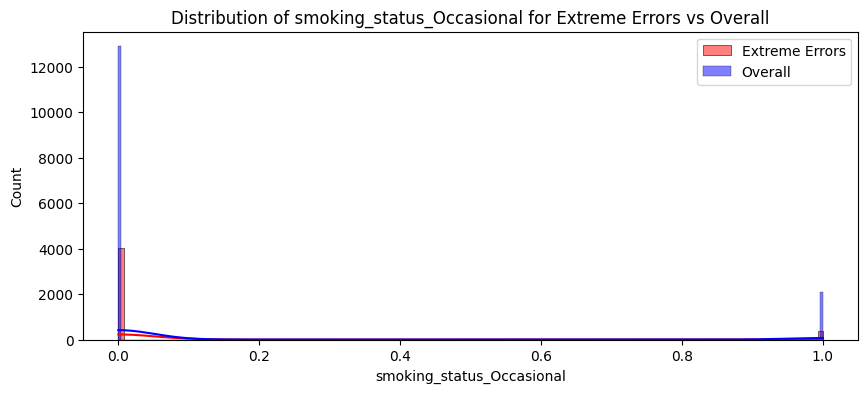

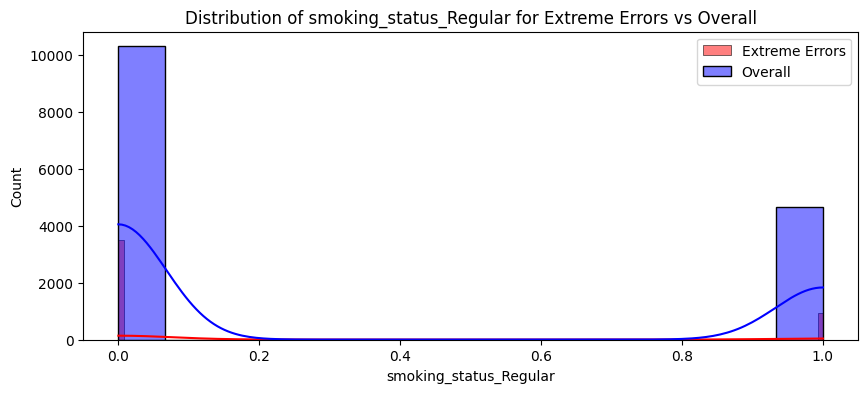

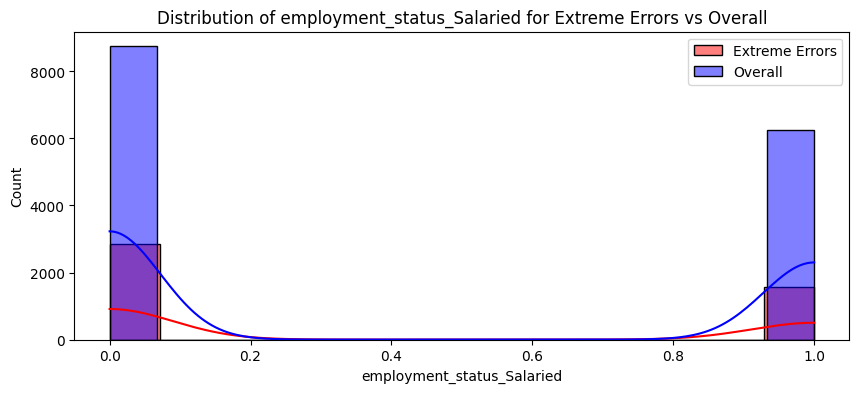

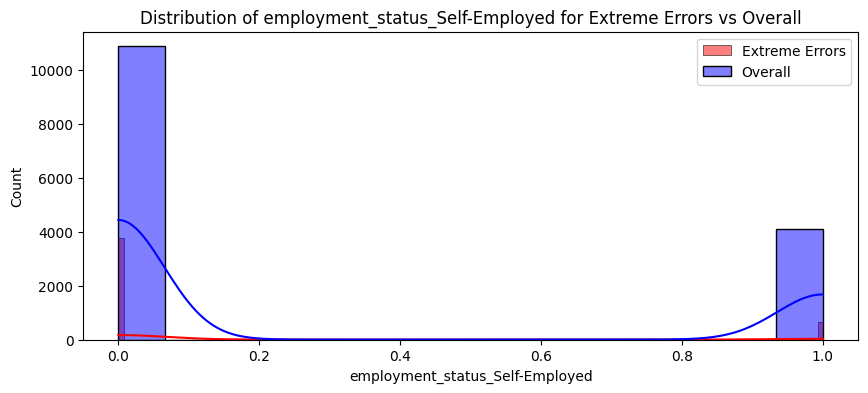

In [113]:
for feature in X_test.columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(extreme_errors_df[feature], color='red', label='Extreme Errors', kde=True)
    sns.histplot(X_test[feature], color='blue', label='Overall', alpha=0.5, kde=True)
    plt.legend()
    plt.title(f'Distribution of {feature} for Extreme Errors vs Overall')
    plt.show()

   ######## EXPORT The MODEL ######
   

In [116]:
from  joblib import dump
dump(best_model, "artifacts/model_xgboost.joblib")


['artifacts/model_xgboost.joblib']

In [117]:
# we have to export scaler also 

scaler_with_cols = {
          "scaler" : scaler,
          "cols_to_scale" : cols_to_scale
}

dump(scaler_with_cols, "artifacts/scaler_with_cols.joblib")

['artifacts/scaler_with_cols.joblib']

In [118]:
scaler_with_cols

{'scaler': MinMaxScaler(),
 'cols_to_scale': ['age',
  'number_of_dependants',
  'income_level',
  'income_lakhs',
  'insurance_plan']}

In [119]:
X_test.head(1)

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
15051,0.500,0.800,0.273,0.500,1.000,1,1,0,0,0,0,0,0,0,0,0,0
